In [262]:
# ======================================================
# Core libraries for respiration + social behavior analysis
# ======================================================

# --- Core Python ---
import os
import h5py
import re

# --- Numerical & data analysis ---
import numpy as np
import pandas as pd

# --- Plotting ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Signal processing ---
from scipy.signal import butter, filtfilt, resample_poly, find_peaks

# --- Statistics ---
from scipy.stats import wilcoxon

# --- Machine learning & metrics ---
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold

# --- Specialized neurophysiology tools ---
import neurokit2 as nk

# --- Pandas display settings ---
pd.set_option("display.max_rows", 50)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 1000)

print("Libraries loaded successfully")


Libraries loaded successfully


In [263]:
# ======================================================
# Define file paths and rank map
# ======================================================

# --- Define social rank map for all subjects ---
rank_map = {
    "1_1": "Subordinate",
    "1_2": "Dominant",
    "2_3": "Subordinate",
    "2_4": "Dominant",
    "3_5": "Subordinate",
    "3_6": "Dominant",
    "4_7": "Subordinate",
    "4_8": "Dominant"
}

# ======================================================
# Respiration + BORIS paths (valence and cagemate sets)
# ======================================================

# --- Valence (RI1, RI2, BLRI) ---
resp_paths = {
    "RI1_3_6": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s3_6_p5_3_nRB3_20250621_125312_merged.h5",
    "RI2_3_6": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s3_6_p5_3_nRB3_20250621_131158_merged.h5",
    "RI1_4_7": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s4_7_p5_2_nRB3_20250621_150707_merged.h5",
    "RI2_4_7": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s4_7_p5_2_nRB3_20250621_152519_merged.h5",
    "RI1_2_3": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s2_3_p5_3_nRB3_20250622_104059_merged (1).h5",
    "RI2_2_3": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s2_3_p5_3_nRB3_20250622_110216_merged.h5",
    "RI1_4_8": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s4_8_p5_1_nRB3_20250621_165214_merged.h5",
    "RI2_4_8": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s4_8_p5_1_nRB3_20250621_171318_merged.h5",
    "RI1_1_1": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s1_1_p5_2_nRB6_20250622_143958_merged.h5",
    "RI2_1_1": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s1_1_p5_2_nRB6_20250622_150457_merged.h5",
    "RI1_1_2": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s1_2_p5_1_nRB6_20250622_170742_merged.h5",
    "RI2_1_2": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s1_2_p5_1_nRB6_20250622_173049_merged.h5",
    "RI1_2_4": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s2_4_p5_4_nRB3_20250622_123424_merged.h5",
    "RI2_2_4": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s2_4_p5_4_nRB3_20250622_125648_merged.h5",
    "RI1_3_5": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s3_5_p5_4_nRB3_20250621_105014_merged.h5",
    "RI2_3_5": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s3_5_p5_4_nRB3_20250621_112618_merged.h5",
    # Baseline recordings (pre-valence)
    "BLRI_1_1": r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s1_1_p5_2_nRB6_20250622_141846_merged.h5",
    "BLRI_1_2": r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s1_2_p5_1_nRB6_20250622_164833_merged.h5",
    "BLRI_2_3": r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s2_3_p5_3_nRB3_20250622_101813_merged.h5",
    "BLRI_2_4": r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s2_4_p5_4_nRB3_20250622_121708_merged.h5",
    "BLRI_3_6": r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s3_6_p5_3_nRB3_20250621_123634_merged.h5",
    "BLRI_4_7": r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s4_7_p5_2_nRB3_20250621_144806_merged.h5",
    "BLRI_4_8": r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s4_8_p5_1_nRB3_20250621_163506_merged.h5",
}

boris_paths = {
    "RI1_3_6": r"E:\Aim1\AIM1\Day1_new\boris\RI1_s3_6_p5_3_nRB3_HEEPS.csv",
    "RI2_3_6": r"E:\Aim1\AIM1\Day1_new\boris\RI2_s3_6_p_5_3_nRB3_2025062.csv",
    "RI1_4_7": r"E:\Aim1\AIM1\Day1_new\boris\RI1_s4_7_p5_2_nRB3_HEEPS.csv",
    "RI2_4_7": r"E:\Aim1\AIM1\Day1_new\boris\RI2_s4_7_p5_2_nRB3_HEEPS.csv",
    "RI1_2_3": r"E:\Aim1\AIM1\Day1_new\boris\RI1_s2_3_p5_3_nRB3_20250622_104059.1.csv",
    "RI2_2_3": r"E:\Aim1\AIM1\Day1_new\boris\RI2_s2_3_p5_3_nRB3_20250622_1102116.1.csv",
    "RI1_4_8": r"E:\Aim1\AIM1\Day1_new\boris\RI1_s4_8_p5_1_nRB3_HEEPS.csv",
    "RI2_4_8": r"E:\Aim1\AIM1\Day1_new\boris\RI2_s4_8_p5_1_nRB3_20250621_HEEPS.csv",
    "RI1_1_1": r"E:\Aim1\AIM1\Day1_new\boris\RI1_s1_1_p5_2_nRB6_20250622_143958.1.csv",
    "RI2_1_1": r"E:\Aim1\AIM1\Day1_new\boris\RI2_s1_1_p5_2_nRB6_20250622_150457.1.csv",
    "RI1_1_2": r"E:\Aim1\AIM1\Day1_new\boris\RI1_s1_2_p5_1_nRB6_20250622_170742.1.csv",
    "RI2_1_2": r"E:\Aim1\AIM1\Day1_new\boris\RI2_s1_2_p5_1_nRB6_20250622_173049.1.csv",
    "RI1_2_4": r"E:\Aim1\AIM1\Day1_new\boris\RI1_s2_4_p5_4_nRB3_20250622_123424.1.csv",
    "RI2_2_4": r"E:\Aim1\AIM1\Day1_new\boris\RI2_s2_4_p5_4_nRB3_20250622_125648.1.csv",
    "RI2_3_5": r"E:\Aim1\AIM1\Day1_new\boris\RI2_s3_5_p5_4_nRB3_20250621.csv",
}

# --- Cagemate interaction (CM) and baselines (BL) ---

resp_paths_bl = {
    "BL_1_1_d1_2": r"E:\Aim1\AIM1\Cagemate_bl_no_ISO\h5_outputs\BL_s1_1_d1_2_20250623_103713_merged.h5",
    "BL_1_2_sub1_1": r"E:\Aim1\AIM1\Cagemate_bl_no_ISO\h5_outputs\BL_s1_2_sub_1_1_20250623_120135_merged.h5",
    "BL_2_3_d2_4": r"E:\Aim1\AIM1\Cagemate_bl_no_ISO\h5_outputs\BL_s2_3_d2_4_20250623_145448_merged.h5",
    "BL_2_4_sub2_3": r"E:\Aim1\AIM1\Cagemate_bl_no_ISO\h5_outputs\BL_s2_4_sub2_3_20250623_141419_merged.h5",
    "BL_3_5_d3_6": r"E:\Aim1\AIM1\Cagemate_bl_no_ISO\h5_outputs\BL_s3_5_d3_6_20250623_154154_merged.h5",
    "BL_3_6_sub3_5": r"E:\Aim1\AIM1\Cagemate_bl_no_ISO\h5_outputs\BL_s3_6_sub3_5_20250623_172635_merged.h5",
    "BL_4_7_d4_8": r"E:\Aim1\AIM1\Cagemate_bl_no_ISO\h5_outputs\BL_s4_7_d4_8_20250623_185042_merged.h5",
    "BL_4_8_sub4_7": r"E:\Aim1\AIM1\Cagemate_bl_no_ISO\h5_outputs\BL_s4_8_sub4_7_20250623_180810_merged.h5"
}

resp_paths_cm = {
    "CM_1_1_d1_2": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\baseline_cagemate_interactions_h5_outputs\CM_s1_1_d1_2_20250623_111352_merged.h5",
    "CM_1_2_sub1_1": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\baseline_cagemate_interactions_h5_outputs\CM_s1_2_sub1_1_20250623_133932_merged.h5",
    "CM_2_3_d2_4": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\baseline_cagemate_interactions_h5_outputs\CM_s2_3_d2_4_20250623_151153_merged.h5",
    "CM_2_4_sub2_3": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\baseline_cagemate_interactions_h5_outputs\CM_s2_4_sub2_3_20250623_143348_merged.h5",
    "CM_3_5_d3_6": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\baseline_cagemate_interactions_h5_outputs\CM_s3_5_d3_6_20250623_170708_merged.h5",
    "CM_3_6_sub3_5": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\baseline_cagemate_interactions_h5_outputs\CM_s3_6_sub3_5_20250623_174348_merged.h5",
    "CM_4_7_d4_8": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\baseline_cagemate_interactions_h5_outputs\CM_s4_7_d4_8_20250623_193718_merged.h5",
    "CM_4_8_sub4_7": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\baseline_cagemate_interactions_h5_outputs\CM_s4_8_sub4_7_20250623_182649_merged.h5",
}

boris_paths_cm = {
    "CM_1_1_d1_2": r"E:\Aim1\AIM1\Day1_new\cm_boris\baseline csv\CM_s1_1_d1_2_20250623_111352.1.csv",
    "CM_1_2_sub1_1": r"E:\Aim1\AIM1\Day1_new\cm_boris\baseline csv\CM_s1_2_sub1_1_20250623_133932.1_VT.csv",
    "CM_2_3_d2_4": r"E:\Aim1\AIM1\Day1_new\cm_boris\baseline csv\CM_s2_3_d2_4_20250623_151153.1.csv",
    "CM_2_4_sub2_3": r"E:\Aim1\AIM1\Day1_new\cm_boris\baseline csv\CM_s2_4_sub2_3_20250623_143348.1_VT.csv",
    "CM_3_5_d3_6": r"E:\Aim1\AIM1\Day1_new\cm_boris\baseline csv\CM_s3_5_d3_6_20250623_160001.csv",
    "CM_3_6_sub3_5": r"E:\Aim1\AIM1\Day1_new\cm_boris\baseline csv\CM_s3_6_sub3_5_20250623_174348.csv",
    "CM_4_7_d4_8": r"E:\Aim1\AIM1\Day1_new\cm_boris\baseline csv\CM_s4_7_d4_8_20250623_193718.csv",
    "CM_4_8_sub4_7": r"E:\Aim1\AIM1\Day1_new\cm_boris\baseline csv\CM_s4_8_sub4_7_20250623_182649.1_VT.csv",
}

# ======================================================
# Summary check
# ======================================================

def summarize_paths(resp_dict, boris_dict, label):
    resp_set = set(resp_dict.keys())
    boris_set = set(boris_dict.keys())
    missing = resp_set - boris_set
    print(f"\n {label} summary")
    print(f"Resp files: {len(resp_set)} | BORIS files: {len(boris_set)} | No BORIS: {len(missing)}")
    if missing:
        print("Missing trials:", ", ".join(sorted(missing)))

# ======================================================
# Organized summaries by experiment type
# ======================================================

# --- Split out subsets for clarity ---
resp_paths_valence = {k: v for k, v in resp_paths.items() if k.startswith(("RI1", "RI2"))}
resp_paths_blri = {k: v for k, v in resp_paths.items() if k.startswith("BLRI")}
resp_paths_cm_only = {k: v for k, v in resp_paths_cm.items() if k.startswith("CM")}
resp_paths_bl_only = {k: v for k, v in resp_paths_bl.items() if k.startswith("BL")}

# Filter BORIS dicts by matching prefixes
boris_paths_valence = {k: v for k, v in boris_paths.items() if k.startswith(("RI1", "RI2"))}
boris_paths_blri = {k: v for k, v in boris_paths.items() if k.startswith("BLRI")}
boris_paths_cm_only = {k: v for k, v in boris_paths_cm.items() if k.startswith("CM")}
boris_paths_bl_only = {k: v for k, v in boris_paths_cm.items() if k.startswith("BL")}

summarize_paths(resp_paths_valence, boris_paths_valence, "Valence (RI1/RI2)")
summarize_paths(resp_paths_blri, boris_paths_blri, "Pre-Valence Baseline (BLRI)")
summarize_paths(resp_paths_cm_only, boris_paths_cm_only, "Cagemate (CM)")
summarize_paths(resp_paths_bl_only, boris_paths_bl_only, "Pre-Cagemate Baseline (BL)")


# ======================================================
# Combine all for unified processing later
# ======================================================
all_resp_paths = {**resp_paths_valence, **resp_paths_blri, **resp_paths_cm_only, **resp_paths_bl_only}
all_boris_paths = {**boris_paths, **boris_paths_cm}

print(f"\n Combined respiration files total: {len(all_resp_paths)}")
print(f" Combined BORIS files total: {len(all_boris_paths)}")

missing_boris = [k for k in all_resp_paths if k not in all_boris_paths]
print(f" Respiration-only trials (no BORIS): {len(missing_boris)}")
if missing_boris:
    print(', '.join(sorted(missing_boris)))




 Valence (RI1/RI2) summary
Resp files: 16 | BORIS files: 15 | No BORIS: 1
Missing trials: RI1_3_5

 Pre-Valence Baseline (BLRI) summary
Resp files: 7 | BORIS files: 0 | No BORIS: 7
Missing trials: BLRI_1_1, BLRI_1_2, BLRI_2_3, BLRI_2_4, BLRI_3_6, BLRI_4_7, BLRI_4_8

 Cagemate (CM) summary
Resp files: 8 | BORIS files: 8 | No BORIS: 0

 Pre-Cagemate Baseline (BL) summary
Resp files: 8 | BORIS files: 0 | No BORIS: 8
Missing trials: BL_1_1_d1_2, BL_1_2_sub1_1, BL_2_3_d2_4, BL_2_4_sub2_3, BL_3_5_d3_6, BL_3_6_sub3_5, BL_4_7_d4_8, BL_4_8_sub4_7

 Combined respiration files total: 39
 Combined BORIS files total: 23
 Respiration-only trials (no BORIS): 16
BLRI_1_1, BLRI_1_2, BLRI_2_3, BLRI_2_4, BLRI_3_6, BLRI_4_7, BLRI_4_8, BL_1_1_d1_2, BL_1_2_sub1_1, BL_2_3_d2_4, BL_2_4_sub2_3, BL_3_5_d3_6, BL_3_6_sub3_5, BL_4_7_d4_8, BL_4_8_sub4_7, RI1_3_5


In [265]:
csv_path = r"E:\Aim1\AIM1\Day1_new\boris\RI1_s3_6_p5_3_nRB3_HEEPS.csv"


In [266]:
import pandas as pd

df = pd.read_csv(csv_path)

print(df.columns.tolist())


['Observation id', 'Observation date', 'Description', 'Observation type', 'Source', 'Time offset (s)', 'Coding duration', 'Media duration (s)', 'FPS (frame/s)', 'Subject', 'Observation duration by subject by observation', 'Behavior', 'Behavioral category', 'Behavior type', 'Start (s)', 'Stop (s)', 'Duration (s)', 'Media file name', 'Image index start', 'Image index stop', 'Image file path start', 'Image file path stop', 'Comment start', 'Comment stop']


In [267]:
import pandas as pd

summary = []

for key, path in boris_paths.items():
    try:
        df = pd.read_csv(path)
        cols = set(df.columns)

        summary.append({
            "session": key,
            "has_image_start": "Image index start" in cols,
            "has_image_stop": "Image index stop" in cols,
            "has_start_sec": "Start (s)" in cols,
            "has_stop_sec": "Stop (s)" in cols,
            "n_rows": len(df)
        })

    except Exception as e:
        summary.append({
            "session": key,
            "error": str(e)
        })

summary_df = pd.DataFrame(summary)
summary_df


,session,has_image_start,has_image_stop,has_start_sec,has_stop_sec,n_rows
0,RI1_3_6,True,True,True,True,37
1,RI2_3_6,True,True,True,True,109
2,RI1_4_7,True,True,True,True,37
3,RI2_4_7,True,True,True,True,108
4,RI1_2_3,False,False,True,True,29
5,RI2_2_3,False,False,True,True,82
6,RI1_4_8,True,True,True,True,55
7,RI2_4_8,True,True,True,True,113
8,RI1_1_1,False,False,True,True,92
9,RI2_1_1,False,False,True,True,37


In [264]:
import pandas as pd

def load_clean_boris(csv_path):
    """
    Load a BORIS CSV file and standardize columns for behavior alignment.

    Returns
    -------
    df : DataFrame
        Columns: ['Behavior', 'Subject', 'Start', 'Stop', 'Duration']
        Keeps only 'subject' rows and social behaviors.
    """
    try:
        df = pd.read_csv(csv_path)
    except Exception as e:
        print(f"⚠️ Could not load {csv_path}: {e}")
        return pd.DataFrame()

    # --- Detect and rename possible column variants ---
    rename_map = {
        "Behavior": "Behavior",
        "Subject": "Subject",
        "Start (s)": "Start",
        "Stop (s)": "Stop",
        "Duration (s)": "Duration",
        "Start": "Start",
        "Stop": "Stop",
        "Duration": "Duration"
    }
    df = df.rename(columns=rename_map)

    # --- Keep essential columns only ---
    keep_cols = [c for c in ["Behavior", "Subject", "Start", "Stop", "Duration"] if c in df.columns]
    df = df[keep_cols].copy()

    # --- Clean ---
    df = df.dropna(subset=["Behavior", "Subject", "Start", "Stop"])
    df["Behavior"] = df["Behavior"].str.lower().str.strip()
    df["Subject"] = df["Subject"].str.lower().str.strip()

    # --- Keep only subject-initiated behaviors ---
    df = df[df["Subject"] == "subject"]

    # --- Focus on relevant social behaviors ---
    behaviors_keep = ["facial sniffing", "body sniffing", "anogenital sniffing"]
    df = df[df["Behavior"].isin(behaviors_keep)]

    # --- Sort chronologically ---
    df = df.sort_values("Start").reset_index(drop=True)

    return df


In [94]:
boris_path = r"E:\Aim1\AIM1\Day1_new\boris\RI1_s1_2_p5_1_nRB6_20250622_170742.1.csv"
boris_df = load_clean_boris(boris_path)

print(boris_df.head())


              Behavior  Subject   Start    Stop  Duration
0        body sniffing  subject  16.155  18.200     2.045
1        body sniffing  subject  19.300  21.767     2.467
2        body sniffing  subject  23.833  25.100     1.267
3  anogenital sniffing  subject  25.567  26.867     1.300
4        body sniffing  subject  27.233  27.833     0.600


In [95]:
def load_clean_resp_signal(h5_file, target_rate=100):
    """
    Loads, filters, downsamples respiration from .h5, returns cleaned signal, time vector, and metadata.
    """
    try:
        with h5py.File(h5_file, 'r') as f:
            resp = f['resp'][:].flatten()

            # Load metadata if available
            metadata = {}
            if 'resp_metadata' in f:
                metadata.update(dict(f['resp_metadata'].attrs))
            if 'ekg_metadata' in f:
                metadata.update(dict(f['ekg_metadata'].attrs))
            if 'metadata' in f:
                metadata.update(dict(f['metadata'].attrs))

            # Estimate sampling frequency
            if 'sampling_frequency' in metadata:
                fs = metadata['sampling_frequency']
            else:
                duration_sec = metadata.get('duration_sec', None)
                fs = len(resp) / duration_sec if duration_sec else 20000.0

            duration_sec = metadata.get('duration_sec', len(resp) / fs)

    except Exception as e:
        print(f"Error loading {h5_file}: {e}")
        return None, None, None, None

    # Pre-filter before downsampling
    nyquist = fs / 2
    norm_cutoff = (target_rate / 2) / nyquist
    b, a = butter(N=4, Wn=norm_cutoff, btype='low')
    filtered_resp = filtfilt(b, a, resp)

    # Downsample
    downsample_factor = int(fs // target_rate)
    downsampled = resample_poly(filtered_resp, up=1, down=downsample_factor)

    # Bandpass filter with neurokit
    rsp_cleaned = nk.signal_filter(
        downsampled,
        lowcut=0.1,
        highcut=20,
        method="butterworth",
        sampling_rate=target_rate,
        order=2
    )

    # Generate matching time vector
    time_vector = np.arange(len(rsp_cleaned)) / target_rate

    return rsp_cleaned, time_vector, target_rate, metadata


In [96]:
def get_sniff_respiratory_rate(signal, time, sniff_start, sniff_end, sampling_rate=100):
    # mask the signal window
    sniff_mask = (time >= sniff_start) & (time < sniff_end)
    signal_sniff = signal[sniff_mask]
    time_sniff = time[sniff_mask]

    # detect peaks with a tighter minimum distance 12 Hz max rate)
    peaks, _ = find_peaks(signal_sniff, distance=sampling_rate * 0.0833)  # 0.0833 s = 12 Hz
    peak_times = time_sniff[peaks]

    # need at least 2 peaks to compute IBI
    if len(peak_times) < 2:
        return np.nan

    # compute IBI
    ibi = np.diff(peak_times)  # seconds

    # instantaneous rate
    inst_rate = 1.0 / ibi      # Hz

    # return average instantaneous rate (one number, same format as old code)
    avg_rate = np.mean(inst_rate)

    return avg_rate


In [97]:
def get_instantaneous_resp_rate(signal, time, sampling_rate=100):
    """
    Computes inter-breath intervals (IBI) and instantaneous respiration rate (Hz).

    Parameters
    ----------
    signal : np.ndarray
        Cleaned respiration trace (filtered and downsampled).
    time : np.ndarray
        Time vector (seconds).
    sampling_rate : float, default=100
        Sampling rate of respiration signal (Hz).

    Returns
    -------
    ibi : np.ndarray
        Inter-breath intervals (seconds).
    inst_rate : np.ndarray
        Instantaneous respiration rate (Hz = 1 / IBI).
    inst_time : np.ndarray
        Time vector aligned to each instantaneous rate (midpoint between consecutive peaks).
    peaks : np.ndarray
        Indices of detected peaks.
    """
    min_distance = int(sampling_rate * 0.0833)  # 12 Hz upper cutoff
    peaks, _ = find_peaks(signal, distance=min_distance)

    if len(peaks) < 2:
        print("Warning: insufficient peaks for IBI calculation")
        return np.array([]), np.array([]), np.array([]), peaks

    peak_times = time[peaks]
    ibi = np.diff(peak_times)
    inst_rate = 1.0 / ibi
    inst_time = peak_times[:-1] + ibi / 2

    return ibi, inst_rate, inst_time, peaks


In [98]:
import matplotlib.pyplot as plt

def plot_instantaneous_resp(signal, time, inst_time, inst_rate, peaks=None, title="Instantaneous Respiration Rate"):
    """
    Plots respiration signal with detected peaks and instantaneous rate over time.

    Parameters
    ----------
    signal : np.ndarray
        Cleaned respiration trace.
    time : np.ndarray
        Time vector (seconds).
    inst_time : np.ndarray
        Midpoints of inter-breath intervals (s).
    inst_rate : np.ndarray
        Instantaneous respiration rate (Hz = 1/IBI).
    peaks : np.ndarray or None
        Optional indices of detected inhalation peaks.
    title : str
        Figure title.
    """
    fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True,
                           gridspec_kw={'height_ratios': [2, 1]})

    # --- Top: respiration signal ---
    ax[0].plot(time, signal, color="gray", lw=1.0)
    if peaks is not None and len(peaks) > 0:
        ax[0].plot(time[peaks], signal[peaks], "r.", markersize=4)
    ax[0].set_ylabel("Amplitude (a.u.)")
    ax[0].set_title(title)
    ax[0].grid(True, linestyle=":", alpha=0.5)

    # --- Bottom: instantaneous rate ---
    ax[1].plot(inst_time, inst_rate, color="teal", lw=1.5)
    ax[1].set_xlabel("Time (s)")
    ax[1].set_ylabel("Rate (Hz)")
    ax[1].grid(True, linestyle=":", alpha=0.5)

    plt.tight_layout()
    plt.show()


In [99]:
# --- Pick one session to test ---
trial_key = "CM_2_4_sub2_3"
resp_path = resp_paths_cm[trial_key]

# --- Load respiration ---
resp_signal, time, fs, meta = load_clean_resp_signal(resp_path)

# --- Compute session-wide respiration rate ---
sniff_start = time[0]
sniff_end = time[-1]

avg_rate = get_sniff_respiratory_rate(
    signal=resp_signal,
    time=time,
    sniff_start=sniff_start,
    sniff_end=sniff_end,
    sampling_rate=fs
)

# --- Extract identifiers automatically ---
condition = trial_key.split("_")[0]              # e.g., "CM"
subject_id = "_".join(trial_key.split("_")[1:3]) # e.g., "2_4"

# --- Print summary ---
print(f"Session: {condition} | Subject: {subject_id}")
print(f"Average respiration rate: {avg_rate:.2f} Hz")
print(f"Sampling rate: {fs:.0f} Hz | Duration: {time[-1]:.1f} sec")


Session: CM | Subject: 2_4
Average respiration rate: 7.49 Hz
Sampling rate: 100 Hz | Duration: 622.0 sec


In [100]:
def process_all_trials(resp_paths, boris_paths, rank_map, duration_threshold=0.5):
    """
    Loops through respiration & BORIS files, computes mean respiration per bout,
    and preserves sessions even when BORIS is missing (resp-only baseline).
    """
    all_trials = []

    for trial, h5_path in resp_paths.items():
        print(f"Processing {trial}...")

        # --- Load respiration ---
        signal, time, fs, meta = load_clean_resp_signal(h5_path)
        if signal is None:
            print(f"❌ Resp load failed for {trial}")
            continue

        # --- Compute session-wide rate ---
        session_rate = get_sniff_respiratory_rate(
            signal=signal,
            time=time,
            sniff_start=time[0],
            sniff_end=time[-1],
            sampling_rate=fs
        )
        print(f"Session-wide respiratory rate for {trial}: {session_rate:.3f} Hz")

        # --- Determine subject, condition, rank ---
        subj = "_".join(trial.split("_")[1:3])
        condition = trial.split("_")[0]
        rank = rank_map.get(subj, np.nan)

        # --- Try loading BORIS ---
        if trial in boris_paths:
            boris_df = load_clean_boris(boris_paths[trial])
        else:
            boris_df = pd.DataFrame()  # missing BORIS entirely

        # --- Handle missing BORIS (resp-only) ---
        if boris_df.empty:
            print(f"⚠️ No BORIS data for {trial} — saving respiration-only session")
            all_trials.append(pd.DataFrame([{
                "Behavior": np.nan,
                "Start": np.nan,
                "Stop": np.nan,
                "Duration": np.nan,
                "MeanRate": np.nan,
                "Trial": trial,
                "Subject": subj,
                "Condition": condition,
                "Rank": rank,
                "SessionRate": session_rate,
                "Type": "Baseline"
            }]))
            continue

        # --- Compute respiration rate per behavior window ---
        boris_df["MeanRate"] = boris_df.apply(
            lambda row: get_sniff_respiratory_rate(
                signal, time, row["Start"], row["Stop"], sampling_rate=fs
            ),
            axis=1
        )

        # --- Filter short bouts ---
        pre_len = len(boris_df)
        boris_df = boris_df[boris_df["Duration"] >= duration_threshold].copy()
        post_len = len(boris_df)
        if pre_len != post_len:
            print(f"   → Filtered {pre_len - post_len} short bouts (<{duration_threshold}s)")

        # --- Add metadata ---
        boris_df["Trial"] = trial
        boris_df["Subject"] = subj
        boris_df["Condition"] = condition
        boris_df["Rank"] = rank
        boris_df["SessionRate"] = session_rate
        boris_df["Type"] = "Interaction"

        all_trials.append(boris_df)

    # --- Combine everything ---
    if not all_trials:
        print("⚠️ No valid trials processed.")
        return pd.DataFrame()

    master_df = pd.concat(all_trials, ignore_index=True)
    print(f"✅ Combined {len(master_df)} behavior windows across {len(all_trials)} trials.")
    print("Unique session types:", master_df["Type"].unique())
    return master_df


In [101]:
def process_all_trials_bout_level(
    resp_paths,
    boris_paths,
    rank_map,
    duration_threshold=0.5
):
    """
    Processes trials at the BOUT level.
    Each row = one behavioral bout with a respiration summary.
    Baseline sessions are stored as pseudo-bouts.
    """
    all_trials = []

    for trial, h5_path in resp_paths.items():
        print(f"Processing {trial}...")

        # --- Load respiration ---
        signal, time, fs, meta = load_clean_resp_signal(h5_path)
        if signal is None:
            print(f"❌ Resp load failed for {trial}")
            continue

        # --- Session-wide respiration rate ---
        session_rate = get_sniff_respiratory_rate(
            signal=signal,
            time=time,
            sniff_start=time[0],
            sniff_end=time[-1],
            sampling_rate=fs
        )

        # --- Metadata ---
        subj = "_".join(trial.split("_")[1:3])
        condition = trial.split("_")[0]
        rank = rank_map.get(subj, np.nan)

        # --- Load BORIS if available ---
        if trial in boris_paths:
            boris_df = load_clean_boris(boris_paths[trial])
        else:
            boris_df = pd.DataFrame()

        # ============================
        # Baseline-only session
        # ============================
        if boris_df.empty:
            print(f"⚠️ No BORIS data for {trial} — saving baseline pseudo-bout")

            all_trials.append(pd.DataFrame([{
                "BoutID": 0,
                "Behavior": "Baseline",
                "Start": time[0],
                "Stop": time[-1],
                "Duration": time[-1] - time[0],
                "BoutRespRate": session_rate,
                "Trial": trial,
                "Subject": subj,
                "Condition": condition,
                "Rank": rank,
                "SessionRate": session_rate,
                "Type": "Baseline"
            }]))
            continue

        # ============================
        # Bout-level respiration
        # ============================
        boris_df["BoutRespRate"] = boris_df.apply(
            lambda row: get_sniff_respiratory_rate(
                signal, time, row["Start"], row["Stop"], sampling_rate=fs
            ),
            axis=1
        )

        # --- Filter short bouts ---
        pre_len = len(boris_df)
        boris_df = boris_df[boris_df["Duration"] >= duration_threshold].copy()
        post_len = len(boris_df)
        if pre_len != post_len:
            print(f"   → Filtered {pre_len - post_len} short bouts")

        # --- Add metadata ---
        boris_df["BoutID"] = np.arange(len(boris_df))
        boris_df["Trial"] = trial
        boris_df["Subject"] = subj
        boris_df["Condition"] = condition
        boris_df["Rank"] = rank
        boris_df["SessionRate"] = session_rate
        boris_df["Type"] = "Interaction"

        all_trials.append(boris_df)

    # --- Combine ---
    if not all_trials:
        print("⚠️ No valid trials processed.")
        return pd.DataFrame()

    master_df = pd.concat(all_trials, ignore_index=True)

    print(f"✅ {len(master_df)} bouts across {master_df['Trial'].nunique()} trials")
    print("Types:", master_df["Type"].unique())

    return master_df


In [102]:
def process_all_trials_bout_level(
    resp_paths,
    boris_paths,
    rank_map,
    duration_threshold=0.5,
    pre_bout_window=2.0  # seconds before bout (optional)
):
    """
    Processes trials at the BOUT level.
    Each row = one behavioral bout with respiration metrics.
    Baseline sessions are stored as pseudo-bouts.
    """
    all_trials = []

    for trial, h5_path in resp_paths.items():
        print(f"Processing {trial}...")

        # --- Load respiration ---
        signal, time, fs, meta = load_clean_resp_signal(h5_path)
        if signal is None:
            print(f"❌ Resp load failed for {trial}")
            continue

        # --- Session-wide respiration rate (instantaneous 1/IBI) ---
        session_rate = get_sniff_respiratory_rate(
            signal=signal,
            time=time,
            sniff_start=time[0],
            sniff_end=time[-1],
            sampling_rate=fs
        )

        # --- Metadata ---
        subj = "_".join(trial.split("_")[1:3])
        condition = trial.split("_")[0]
        rank = rank_map.get(subj, np.nan)

        # --- Load BORIS if available ---
        if trial in boris_paths:
            boris_df = load_clean_boris(boris_paths[trial])
        else:
            boris_df = pd.DataFrame()

        # ============================
        # Baseline-only session
        # ============================
        if boris_df.empty:
            print(f"⚠️ No BORIS data for {trial} — saving baseline pseudo-bout")

            all_trials.append(pd.DataFrame([{
                "BoutID": 0,
                "Behavior": "Baseline",
                "Start": time[0],
                "Stop": time[-1],
                "Duration": time[-1] - time[0],
                "BoutRespRate": session_rate,
                "PreBoutRespRate": np.nan,
                "Trial": trial,
                "Subject": subj,
                "Condition": condition,
                "Rank": rank,
                "SessionRate": session_rate,
                "Type": "Baseline"
            }]))
            continue

        # ============================
        # Bout-level respiration
        # ============================
        def compute_bout_metrics(row):
            # --- Bout respiration ---
            bout_rate = get_sniff_respiratory_rate(
                signal, time,
                row["Start"], row["Stop"],
                sampling_rate=fs
            )

            # --- Pre-bout respiration ---
            pre_start = max(time[0], row["Start"] - pre_bout_window)
            pre_stop = row["Start"]

            if pre_stop <= pre_start:
                pre_rate = np.nan
            else:
                pre_rate = get_sniff_respiratory_rate(
                    signal, time,
                    pre_start, pre_stop,
                    sampling_rate=fs
                )

            return pd.Series({
                "BoutRespRate": bout_rate,
                "PreBoutRespRate": pre_rate
            })

        boris_df[["BoutRespRate", "PreBoutRespRate"]] = (
            boris_df.apply(compute_bout_metrics, axis=1)
        )

        # --- Filter short bouts ---
        pre_len = len(boris_df)
        boris_df = boris_df[boris_df["Duration"] >= duration_threshold].copy()
        post_len = len(boris_df)
        if pre_len != post_len:
            print(f"   → Filtered {pre_len - post_len} short bouts")

        # --- Add metadata ---
        boris_df["BoutID"] = np.arange(len(boris_df))
        boris_df["Trial"] = trial
        boris_df["Subject"] = subj
        boris_df["Condition"] = condition
        boris_df["Rank"] = rank
        boris_df["SessionRate"] = session_rate
        boris_df["Type"] = "Interaction"

        all_trials.append(boris_df)

    # ============================
    # Combine all trials
    # ============================
    if not all_trials:
        print("⚠️ No valid trials processed.")
        return pd.DataFrame()

    master_df = pd.concat(all_trials, ignore_index=True)

    # ============================
    # Optional derived features
    # ============================
    master_df["BoutRespRate_pre_delta"] = (
        master_df["BoutRespRate"] - master_df["PreBoutRespRate"]
    )

    master_df["BoutRespRate_z"] = (
        master_df
        .groupby("Trial")["BoutRespRate"]
        .transform(lambda x: (x - x.mean()) / x.std() if x.std() > 0 else np.nan)
    )

    print(f"✅ {len(master_df)} bouts across {master_df['Trial'].nunique()} trials")
    print("Types:", master_df["Type"].unique())

    return master_df


In [103]:
# ======================================================
# Process all trial sets (Valence, Cagemate, Baseline)
# ======================================================

print("\n==============================")
print("Processing Valence (RI1/RI2/BLRI)")
print("==============================")
master_df_valence = process_all_trials_bout_level(resp_paths, boris_paths, rank_map)

print("\n==============================")
print("Processing Cagemate (CM)")
print("==============================")
master_df_cm = process_all_trials_bout_level(resp_paths_cm, boris_paths_cm, rank_map)

print("\n==============================")
print("Processing Pre-Cagemate Baseline (BL)")
print("==============================")
master_df_bl = process_all_trials(resp_paths_bl, {}, rank_map)

# --- Combine all into one master DataFrame ---
print("\n==============================")
print("Combining all master DataFrames")
print("==============================")

master_df = pd.concat(
    [master_df_valence, master_df_cm, master_df_bl],
    ignore_index=True
)

print(f" Final combined dataset: {len(master_df)} rows total")
print("Unique conditions:", master_df['Condition'].unique())
print("Unique ranks:", master_df['Rank'].unique())



Processing Valence (RI1/RI2/BLRI)
Processing RI1_3_6...
   → Filtered 4 short bouts
Processing RI2_3_6...
   → Filtered 12 short bouts
Processing RI1_4_7...
   → Filtered 3 short bouts
Processing RI2_4_7...
   → Filtered 1 short bouts
Processing RI1_2_3...
Processing RI2_2_3...
Processing RI1_4_8...
   → Filtered 8 short bouts
Processing RI2_4_8...
   → Filtered 1 short bouts
Processing RI1_1_1...
   → Filtered 4 short bouts
Processing RI2_1_1...
Processing RI1_1_2...
   → Filtered 13 short bouts
Processing RI2_1_2...
   → Filtered 2 short bouts
Processing RI1_2_4...
   → Filtered 7 short bouts
Processing RI2_2_4...
   → Filtered 2 short bouts
Processing RI1_3_5...
⚠️ No BORIS data for RI1_3_5 — saving baseline pseudo-bout
Processing RI2_3_5...
   → Filtered 3 short bouts
Processing BLRI_1_1...
⚠️ No BORIS data for BLRI_1_1 — saving baseline pseudo-bout
Processing BLRI_1_2...
⚠️ No BORIS data for BLRI_1_2 — saving baseline pseudo-bout
Processing BLRI_2_3...
⚠️ No BORIS data for BLRI_2

For each behavior window:

It extracts only the part of the respiration signal between Start and Stop.

It detects inhalation peaks only within that window.

Computes:

{MeanRate} = # of sniff cycles in that window\length of window in seconds

Why this is different from session rate

SessionRate uses all sniff cycles across the entire recording (e.g., 6 minutes).

MeanRate (bout-level) uses only the sniff cycles occurring during a behavior window (e.g., 1.2 seconds of nose-to-nose sniffing).

This means:

Measure	What it represents	Duration used
SessionRate	baseline/arousal for entire session	full recording
MeanRate	respiration during that specific behavior	behavior window only

They will almost never be the same, because the distribution of sniffs changes depending on whether the mouse is investigating, grooming, still, stressed, etc.

Example to make this intuitive

Suppose the trial is 180 seconds long and the mouse sniffs 450 times total:

Session rate ≈ 450 / 180 = 2.5 Hz

Now look at a BORIS behavior:

Behavior window: 1.0–2.2 sec (duration 1.2 sec)

Sniffs in that window: 5

MeanRate = 5 / 1.2 = 4.17 Hz

These are both respiration rates, but they describe different times.

In [236]:
master_df

,Behavior,Subject,Start,Stop,Duration,BoutRespRate,PreBoutRespRate,BoutID,Trial,Condition,Rank,SessionRate,Type,BoutRespRate_pre_delta,BoutRespRate_z,MeanRate
0,facial sniffing,3_6,11.966,13.000,1.034,8.814815,9.167834,0.0,RI1_3_6,RI1,Dominant,8.078920,Interaction,-0.353019,-0.555753,NaN
1,anogenital sniffing,3_6,14.483,16.690,2.207,9.704521,9.766671,1.0,RI1_3_6,RI1,Dominant,8.078920,Interaction,-0.062151,0.729896,NaN
2,anogenital sniffing,3_6,25.034,27.552,2.518,9.152463,9.388105,2.0,RI1_3_6,RI1,Dominant,8.078920,Interaction,-0.235642,-0.067842,NaN
3,body sniffing,3_6,27.793,28.448,0.655,10.040404,9.167320,3.0,RI1_3_6,RI1,Dominant,8.078920,Interaction,0.873084,1.215257,NaN
4,anogenital sniffing,3_6,28.862,29.861,0.999,9.180884,8.654543,4.0,RI1_3_6,RI1,Dominant,8.078920,Interaction,0.526342,-0.026772,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
476,NaN,2_4,NaN,NaN,NaN,NaN,NaN,NaN,BL_2_4_sub2_3,BL,Dominant,8.471447,Baseline,NaN,NaN,NaN
477,NaN,3_5,NaN,NaN,NaN,NaN,NaN,NaN,BL_3_5_d3_6,BL,Subordinate,8.381803,Baseline,NaN,NaN,NaN
478,NaN,3_6,NaN,NaN,NaN,NaN,NaN,NaN,BL_3_6_sub3_5,BL,Dominant,6.000826,Baseline,NaN,NaN,NaN
479,NaN,4_7,NaN,NaN,NaN,NaN,NaN,NaN,BL_4_7_d4_8,BL,Subordinate,8.282217,Baseline,NaN,NaN,NaN


In [223]:
valence_df = (
    master_df
    .query("Type == 'Interaction' and Condition in ['RI1', 'RI2']")
    .dropna(subset=["BoutRespRate"])
)

X = valence_df[["BoutRespRate"]].to_numpy()
y = (valence_df["Condition"] == "RI1").astype(int).to_numpy()
groups = valence_df["Subject"].to_numpy()

cv = GroupKFold(n_splits=len(np.unique(groups)))
aucs = []

for train_idx, test_idx in cv.split(X, y, groups):
    if len(np.unique(y[test_idx])) < 2:
        continue

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            C=0.1, solver="liblinear", class_weight="balanced"
        ))
    ])

    model.fit(X[train_idx], y[train_idx])
    y_pred = model.predict_proba(X[test_idx])[:, 1]
    aucs.append(roc_auc_score(y[test_idx], y_pred))

print("Valence AUC:", np.mean(aucs))


Valence AUC: 0.6136521046525721


In [224]:
train_bout_counts = []
test_bout_counts = []
used_subjects = []

for train_idx, test_idx in cv.split(X, y, groups):
    # Skip folds without both valences in test
    if len(np.unique(y[test_idx])) < 2:
        continue

    train_bout_counts.append(len(train_idx))
    test_bout_counts.append(len(test_idx))
    used_subjects.append(np.unique(groups[test_idx])[0])


In [225]:
print("\nValence decoder:")
print(f"  Subjects included: {len(used_subjects)} / {len(np.unique(groups))}")
print(f"  Subjects used: {used_subjects}")
print(f"  Total bouts: {len(X)}")
print(f"  Mean training bouts per fold: {np.mean(train_bout_counts):.1f}")
print(f"  Mean test bouts per fold: {np.mean(test_bout_counts):.1f}")
print(f"  Train range: {min(train_bout_counts)}–{max(train_bout_counts)}")
print(f"  Test range: {min(test_bout_counts)}–{max(test_bout_counts)}")



Valence decoder:
  Subjects included: 6 / 8
  Subjects used: ['1_1', '1_2', '2_4', '2_3', '4_7', '3_6']
  Total bouts: 307
  Mean training bouts per fold: 259.5
  Mean test bouts per fold: 47.5
  Train range: 220–283
  Test range: 24–87


In [226]:
train_bout_counts = []
test_bout_counts = []
used_subjects = []

for train_idx, test_idx in cv.split(X, y, groups):
    # Skip folds without both valences in test
    if len(np.unique(y[test_idx])) < 2:
        continue

    train_bout_counts.append(len(train_idx))
    test_bout_counts.append(len(test_idx))
    used_subjects.append(np.unique(groups[test_idx])[0])


In [227]:
print("\nValence decoder:")
print(f"  Subjects included: {len(used_subjects)} / {len(np.unique(groups))}")
print(f"  Total bouts: {len(X)}")
print(f"  Avg training bouts per fold: {np.mean(train_bout_counts):.1f}")
print(f"  Avg test bouts per fold: {np.mean(test_bout_counts):.1f}")



Valence decoder:
  Subjects included: 6 / 8
  Total bouts: 307
  Avg training bouts per fold: 259.5
  Avg test bouts per fold: 47.5


In [ ]:
# --------------------------------------------------
# Dominant–Subordinate subject pairs
# --------------------------------------------------
pair_groups = [
    ["1_1", "1_2"],
    ["2_3", "2_4"],
    ["3_5", "3_6"],
    ["4_7", "4_8"],
]

# --------------------------------------------------
# Prepare BOUT-LEVEL rank data (normalized feature)
# --------------------------------------------------
rank_df = (
    master_df
    .query("Condition == 'CM' and Type == 'Interaction'")
    .dropna(subset=["BoutRespRate_z", "Rank"])
    .copy()
)

X = rank_df[["BoutRespRate", "BoutRespRate_z"]].to_numpy()
y = (rank_df["Rank"] == "Dominant").astype(int).to_numpy()
subjects = rank_df["Subject"].to_numpy()

# --------------------------------------------------
# Leave-One-Pair-Out Cross-Validation
# --------------------------------------------------
aucs = []
print(f"Running Leave-One-Pair-Out CV on {len(pair_groups)} subject pairs...\n")

for pair in pair_groups:
    test_mask = np.isin(subjects, pair)
    train_mask = ~test_mask

    X_train, X_test = X[train_mask], X[test_mask]
    y_train, y_test = y[train_mask], y[test_mask]

    # Skip invalid folds
    if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
        print(f"⚠️ Skipping pair {pair} (missing class)")
        continue

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            C=0.1,
            penalty="l2",
            solver="liblinear",
            class_weight="balanced"
        ))
    ])

    model.fit(X_train, y_train)
    y_pred = model.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, y_pred)
    aucs.append(auc)
    print(f"Pair {pair}: AUC = {auc:.2f}")

# --------------------------------------------------
# Summary
# --------------------------------------------------
if aucs:
    auc_mean = np.mean(aucs)
    auc_sem = np.std(aucs) / np.sqrt(len(aucs))
    print("\n🏆 Leave-One-Pair-Out Rank AUCs:", np.round(aucs, 3))
    print(f"Mean Rank AUC: {auc_mean:.2f} ± {auc_sem:.2f}")
else:
    print("⚠️ No valid folds contained both classes.")


Running Leave-One-Pair-Out CV on 4 subject pairs...

Pair ['1_1', '1_2']: AUC = 0.06
Pair ['2_3', '2_4']: AUC = 0.95
⚠️ Skipping pair ['3_5', '3_6'] (missing class)
Pair ['4_7', '4_8']: AUC = 0.90

🏆 Leave-One-Pair-Out Rank AUCs: [0.063 0.947 0.897]
Mean Rank AUC: 0.64 ± 0.23


Valence AUC: 0.61 ± 0.10


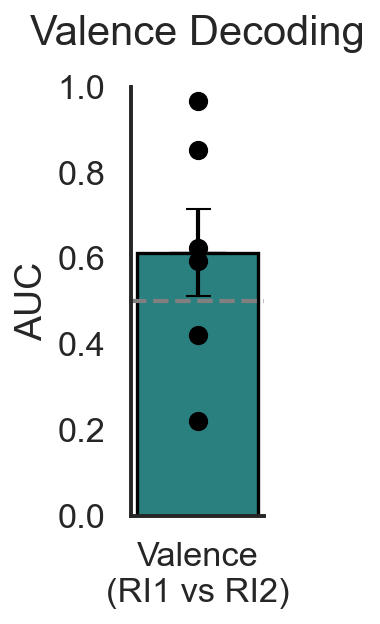

In [210]:
# ----------------------------------
# Prepare BOUT-LEVEL valence data
# ----------------------------------
valence_df = (
    master_df
    .query("Type == 'Interaction' and Condition in ['RI1', 'RI2']")
    .dropna(subset=["BoutRespRate"])
)

X = valence_df[["BoutRespRate"]].to_numpy()
y = (valence_df["Condition"] == "RI1").astype(int).to_numpy()
groups = valence_df["Subject"].to_numpy()

# ----------------------------------
# Leave-One-Subject-Out CV
# ----------------------------------
cv = GroupKFold(n_splits=len(np.unique(groups)))
aucs = []

for train_idx, test_idx in cv.split(X, y, groups):
    if len(np.unique(y[test_idx])) < 2:
        continue

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            C=0.1,
            solver="liblinear",
            class_weight="balanced"
        ))
    ])

    model.fit(X[train_idx], y[train_idx])
    y_pred = model.predict_proba(X[test_idx])[:, 1]
    aucs.append(roc_auc_score(y[test_idx], y_pred))

# ----------------------------------
# Summary statistics
# ----------------------------------
auc_mean = np.mean(aucs)
auc_sem = np.std(aucs) / np.sqrt(len(aucs))

print(f"Valence AUC: {auc_mean:.2f} ± {auc_sem:.2f}")

# ----------------------------------
# Plot: Valence decoder performance
# ----------------------------------
plt.figure(figsize=(2.2, 4.5))

plt.bar(
    ["Valence\n(RI1 vs RI2)"],
    [auc_mean],
    width=0.35,
    color="#2A7F7F",
    edgecolor="black",
    linewidth=1.6
)


# Bar for mean AUC
plt.bar(
    ["Valence\n(RI1 vs RI2)"],
    [auc_mean],
    color="#2A7F7F",
    edgecolor="black",
    linewidth=1.6
)

# Error bar
plt.errorbar(
    x=[0],
    y=[auc_mean],
    yerr=[auc_sem],
    fmt="none",
    ecolor="black",
    capsize=6,
    lw=2
)

# Per-fold dots
plt.scatter(
    np.zeros(len(aucs)),
    aucs,
    color="black",
    s=60,
    zorder=3
)

# Chance line
plt.axhline(0.5, ls="--", color="gray", lw=2)

plt.ylim(0, 1)
plt.ylabel("AUC", fontsize=18)
plt.title("Valence Decoding", pad=20, fontsize=20)

sns.despine()
plt.tight_layout()
plt.show()



In [180]:
pair_groups = [
    ["1_1", "1_2"],
    ["2_3", "2_4"],
    ["3_5", "3_6"],
    ["4_7", "4_8"],
]

rank_df = (
    master_df
    .query("Condition in ['CM', 'BL', 'BLRI'] and Type == 'Interaction'")
    .dropna(subset=["BoutRespRate_z"])
)

X = rank_df[["BoutRespRate", "BoutRespRate_z"]].to_numpy()
y = (rank_df["Rank"] == "Dominant").astype(int).to_numpy()
subjects = rank_df["Subject"].to_numpy()

aucs = []

for pair in pair_groups:
    test_mask = np.isin(subjects, pair)
    train_mask = ~test_mask

    if len(np.unique(y[test_mask])) < 2:
        continue

    model = LogisticRegression(
        C=0.1, solver="liblinear", class_weight="balanced"
    )
    model.fit(X[train_mask], y[train_mask])

    y_pred = model.predict_proba(X[test_mask])[:, 1]
    aucs.append(roc_auc_score(y[test_mask], y_pred))

print("Rank AUC:", np.mean(aucs))


Rank AUC: 0.6329768953906886


Rank AUC: 0.63 ± 0.24


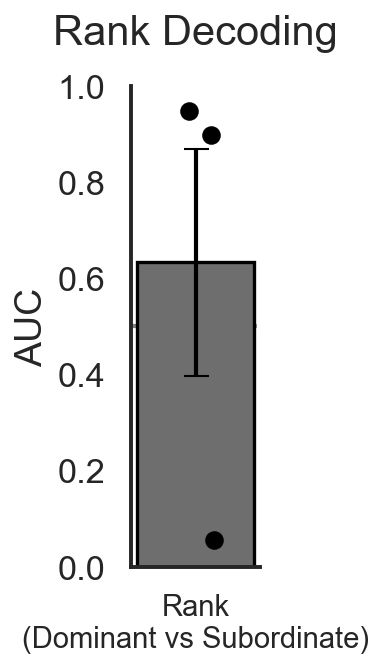

In [217]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# --------------------------------------------------
# Dominant–Subordinate subject pairs
# --------------------------------------------------
pair_groups = [
    ["1_1", "1_2"],
    ["2_3", "2_4"],
    ["3_5", "3_6"],
    ["4_7", "4_8"],
]

# --------------------------------------------------
# Prepare BOUT-LEVEL rank data
# --------------------------------------------------
rank_df = (
    master_df
    .query("Condition in ['CM', 'BL', 'BLRI'] and Type == 'Interaction'")
    .dropna(subset=["BoutRespRate_z"])
)

X = rank_df[["BoutRespRate", "BoutRespRate_z"]].to_numpy()
y = (rank_df["Rank"] == "Dominant").astype(int).to_numpy()
subjects = rank_df["Subject"].to_numpy()

# --------------------------------------------------
# Leave-One-Pair-Out CV
# --------------------------------------------------
aucs = []

for pair in pair_groups:
    test_mask = np.isin(subjects, pair)
    train_mask = ~test_mask

    # Skip invalid folds
    if len(np.unique(y[test_mask])) < 2:
        continue

    model = LogisticRegression(
        C=0.1,
        solver="liblinear",
        class_weight="balanced"
    )

    model.fit(X[train_mask], y[train_mask])
    y_pred = model.predict_proba(X[test_mask])[:, 1]
    aucs.append(roc_auc_score(y[test_mask], y_pred))

# --------------------------------------------------
# Summary statistics
# --------------------------------------------------
auc_mean = np.mean(aucs)
auc_sem = np.std(aucs) / np.sqrt(len(aucs))

print(f"Rank AUC: {auc_mean:.2f} ± {auc_sem:.2f}")

# --------------------------------------------------
# Plot: Rank decoder performance (MATCHES valence)
# --------------------------------------------------
sns.set(style="white", context="talk")
plt.figure(figsize=(2.4, 4.8))

# Mean bar
plt.bar(
    [0],
    [auc_mean],
    width=0.35,
    color="#6E6E6E",  # neutral gray for rank
    edgecolor="black",
    linewidth=1.6,
    zorder=1
)

# Error bar (mean ± SEM)
plt.errorbar(
    0,
    auc_mean,
    yerr=auc_sem,
    fmt="none",
    ecolor="black",
    capsize=6,
    lw=2,
    zorder=3
)

# Jittered per-pair AUCs
jitter = np.random.normal(0, 0.05, size=len(aucs))
plt.scatter(
    jitter,
    aucs,
    color="black",
    s=55,
    zorder=4
)

# Chance line
plt.axhline(0.5, ls="--", color="gray", lw=2, zorder=0)

# Axes
plt.xticks([0], ["Rank\n(Dominant vs Subordinate)"], fontsize=14)
plt.ylabel("AUC", fontsize=18)
plt.ylim(0, 1)
plt.title("Rank Decoding", pad=20, fontsize=20)

sns.despine()
plt.tight_layout()
plt.show()


In [212]:
pair_aucs = []  # list of dicts

for pair in pair_groups:
    test_mask = np.isin(subjects, pair)
    train_mask = ~test_mask

    # Skip invalid folds
    if len(np.unique(y[test_mask])) < 2:
        print(f"Skipping pair {pair} (missing class)")
        continue

    model = LogisticRegression(
        C=0.1,
        solver="liblinear",
        class_weight="balanced"
    )

    model.fit(X[train_mask], y[train_mask])
    y_pred = model.predict_proba(X[test_mask])[:, 1]
    auc = roc_auc_score(y[test_mask], y_pred)

    pair_aucs.append({
        "Pair": f"{pair[0]}–{pair[1]}",
        "AUC": auc,
        "n_test_bouts": np.sum(test_mask),
        "n_train_bouts": np.sum(train_mask)
    })



Skipping pair ['3_5', '3_6'] (missing class)


In [213]:
import pandas as pd

pair_auc_df = pd.DataFrame(pair_aucs)

print("\nRank decoder — per-pair performance:")
display(pair_auc_df)



Rank decoder — per-pair performance:


,Pair,AUC,n_test_bouts,n_train_bouts
0,1_1–1_2,0.055556,23,131
1,2_3–2_4,0.946708,62,92
2,4_7–4_8,0.896667,37,117


In [204]:
train_bout_counts = []
test_bout_counts = []

for pair in pair_groups:
    test_mask = np.isin(subjects, pair)
    train_mask = ~test_mask

    if len(np.unique(y[test_mask])) < 2:
        continue

    train_bout_counts.append(np.sum(train_mask))
    test_bout_counts.append(np.sum(test_mask))

print("Rank decoder:")
print(f"  Total bouts: {len(X)}")
print(f"  Mean training bouts per fold: {np.mean(train_bout_counts):.1f}")
print(f"  Mean test bouts per fold: {np.mean(test_bout_counts):.1f}")


Rank decoder:
  Total bouts: 154
  Mean training bouts per fold: 113.3
  Mean test bouts per fold: 40.7


In [214]:
pair_results = []

for pair in pair_groups:
    test_mask = np.isin(subjects, pair)
    train_mask = ~test_mask

    # Require both classes in test set
    if len(np.unique(y[test_mask])) < 2:
        print(f"Skipping pair {pair} (missing class)")
        continue

    model = LogisticRegression(
        C=0.1,
        solver="liblinear",
        class_weight="balanced"
    )

    model.fit(X[train_mask], y[train_mask])
    y_pred = model.predict_proba(X[test_mask])[:, 1]
    auc = roc_auc_score(y[test_mask], y_pred)

    pair_results.append({
        "pair": f"{pair[0]}–{pair[1]}",
        "auc": auc
    })


Skipping pair ['3_5', '3_6'] (missing class)


In [215]:
labels = [r["pair"] for r in pair_results]
aucs = np.array([r["auc"] for r in pair_results])

auc_mean = aucs.mean()


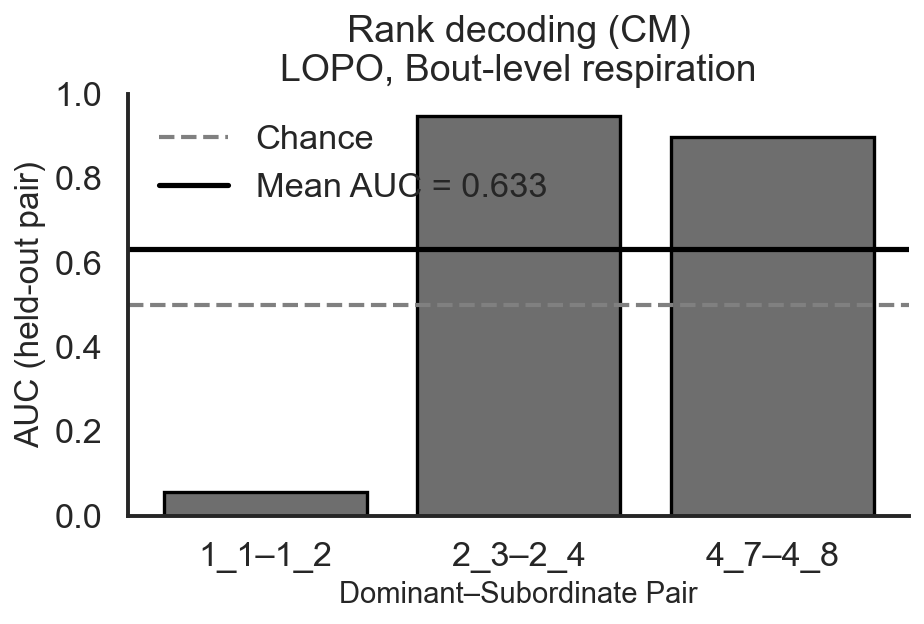

In [216]:
plt.figure(figsize=(6.5, 4.5))

plt.bar(
    labels,
    aucs,
    color="#6E6E6E",      # gray for rank
    edgecolor="black",
    linewidth=1.6
)

# Chance line
plt.axhline(0.5, ls="--", color="gray", lw=2, label="Chance")

# Mean AUC line
plt.axhline(
    auc_mean,
    color="black",
    lw=2.5,
    label=f"Mean AUC = {auc_mean:.3f}"
)

plt.ylim(0, 1)
plt.ylabel("AUC (held-out pair)", fontsize=16)
plt.xlabel("Dominant–Subordinate Pair", fontsize=14)
plt.title("Rank decoding (CM)\nLOPO, Bout-level respiration", fontsize=18)

plt.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.show()


In [202]:
rank_df

,Behavior,Subject,Start,Stop,Duration,BoutRespRate,PreBoutRespRate,BoutID,Trial,Condition,Rank,SessionRate,Type,BoutRespRate_pre_delta,BoutRespRate_z,MeanRate
315,facial sniffing,1_1,18.200,18.700,0.500,8.333333,8.926566,0.0,CM_1_1_d1_2,CM,Subordinate,7.444543,Interaction,-0.593233,0.752362,NaN
316,facial sniffing,1_1,196.467,196.967,0.500,8.838384,5.196413,1.0,CM_1_1_d1_2,CM,Subordinate,7.444543,Interaction,3.641971,1.176773,NaN
317,body sniffing,1_1,218.467,220.233,1.766,7.064602,7.515929,2.0,CM_1_1_d1_2,CM,Subordinate,7.444543,Interaction,-0.451327,-0.313794,NaN
318,anogenital sniffing,1_1,256.667,257.467,0.800,7.487179,7.304095,3.0,CM_1_1_d1_2,CM,Subordinate,7.444543,Interaction,0.183085,0.041312,NaN
319,body sniffing,1_1,258.700,260.566,1.866,6.794178,7.364398,4.0,CM_1_1_d1_2,CM,Subordinate,7.444543,Interaction,-0.570220,-0.541040,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
468,facial sniffing,4_8,375.067,377.267,2.200,8.163395,7.886812,20.0,CM_4_8_sub4_7,CM,Dominant,7.908423,Interaction,0.276583,-0.550016,NaN
469,facial sniffing,4_8,425.533,427.766,2.233,9.133124,6.888015,21.0,CM_4_8_sub4_7,CM,Dominant,7.908423,Interaction,2.245108,0.326147,NaN
470,body sniffing,4_8,427.767,429.467,1.700,9.465210,9.374996,22.0,CM_4_8_sub4_7,CM,Dominant,7.908423,Interaction,0.090214,0.626192,NaN
471,body sniffing,4_8,433.800,434.867,1.067,8.958333,6.459325,23.0,CM_4_8_sub4_7,CM,Dominant,7.908423,Interaction,2.499009,0.168222,NaN


In [178]:
# Train valence model on ALL valence data
valence_df = (
    master_df
    .query("Type == 'Interaction' and Condition in ['RI1', 'RI2']")
    .dropna(subset=["BoutRespRate"])
)

X_val = valence_df[["BoutRespRate"]].to_numpy()
y_val = (valence_df["Condition"] == "RI1").astype(int).to_numpy()

valence_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        C=0.1, solver="liblinear", class_weight="balanced"
    ))
])

valence_model.fit(X_val, y_val)

# Apply to rank data
rank_df = (
    master_df
    .query("Condition in ['CM', 'BL', 'BLRI'] and Type == 'Interaction'")
    .dropna(subset=["BoutRespRate"])
)

X_rank = rank_df[["BoutRespRate"]].to_numpy()
y_rank = (rank_df["Rank"] == "Dominant").astype(int).to_numpy()

y_pred_rank = valence_model.predict_proba(X_rank)[:, 1]
auc_transfer = roc_auc_score(y_rank, y_pred_rank)

print("Valence → Rank transfer AUC:", auc_transfer)


Valence → Rank transfer AUC: 0.3893249607535321


In [228]:
# ----------------------------------
# Report training vs testing size (TRANSFER)
# ----------------------------------

print("\nValence → Rank transfer model:")
print(f"  Training domain: Valence (RI1 vs RI2)")
print(f"    Training bouts: {len(X_val)}")
print(f"    RI1 bouts: {(y_val == 1).sum()}")
print(f"    RI2 bouts: {(y_val == 0).sum()}")

print(f"\n  Testing domain: Rank (Dominant vs Subordinate)")
print(f"    Testing bouts: {len(X_rank)}")
print(f"    Dominant bouts: {(y_rank == 1).sum()}")
print(f"    Subordinate bouts: {(y_rank == 0).sum()}")

print(f"\n  Valence → Rank transfer AUC: {auc_transfer:.3f}")



Valence → Rank transfer model:
  Training domain: Valence (RI1 vs RI2)
    Training bouts: 307
    RI1 bouts: 271
    RI2 bouts: 36

  Testing domain: Rank (Dominant vs Subordinate)
    Testing bouts: 154
    Dominant bouts: 63
    Subordinate bouts: 91

  Valence → Rank transfer AUC: 0.389


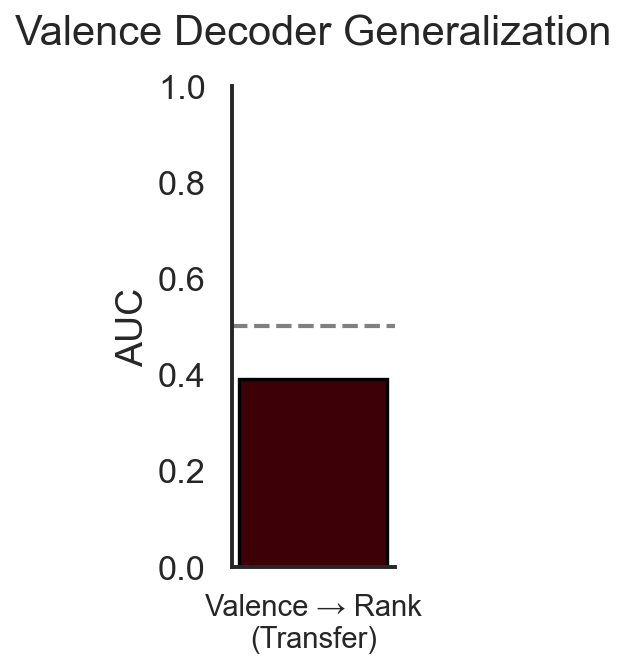

In [229]:
import matplotlib.pyplot as plt
import seaborn as sns

auc_transfer = auc_transfer  # already computed

plt.figure(figsize=(2.4, 4.8))

# Bar
plt.bar(
    [0],
    [auc_transfer],
    width=0.35,
    color="#3D0007",      # distinct transfer color
    edgecolor="black",
    linewidth=1.6
)

# Chance line
plt.axhline(0.5, ls="--", color="gray", lw=2)

# Axis formatting
plt.xticks([0], ["Valence → Rank\n(Transfer)"], fontsize=14)
plt.ylabel("AUC", fontsize=18)
plt.ylim(0, 1)
plt.title("Valence Decoder Generalization", pad=20, fontsize=20)

sns.despine()
plt.tight_layout()
plt.show()


In [104]:
master_df


,Behavior,Subject,Start,Stop,Duration,BoutRespRate,PreBoutRespRate,BoutID,Trial,Condition,Rank,SessionRate,Type,BoutRespRate_pre_delta,BoutRespRate_z,MeanRate
0,facial sniffing,3_6,11.966,13.000,1.034,8.814815,9.167834,0.0,RI1_3_6,RI1,Dominant,8.078920,Interaction,-0.353019,-0.555753,NaN
1,anogenital sniffing,3_6,14.483,16.690,2.207,9.704521,9.766671,1.0,RI1_3_6,RI1,Dominant,8.078920,Interaction,-0.062151,0.729896,NaN
2,anogenital sniffing,3_6,25.034,27.552,2.518,9.152463,9.388105,2.0,RI1_3_6,RI1,Dominant,8.078920,Interaction,-0.235642,-0.067842,NaN
3,body sniffing,3_6,27.793,28.448,0.655,10.040404,9.167320,3.0,RI1_3_6,RI1,Dominant,8.078920,Interaction,0.873084,1.215257,NaN
4,anogenital sniffing,3_6,28.862,29.861,0.999,9.180884,8.654543,4.0,RI1_3_6,RI1,Dominant,8.078920,Interaction,0.526342,-0.026772,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
476,NaN,2_4,NaN,NaN,NaN,NaN,NaN,NaN,BL_2_4_sub2_3,BL,Dominant,8.471447,Baseline,NaN,NaN,NaN
477,NaN,3_5,NaN,NaN,NaN,NaN,NaN,NaN,BL_3_5_d3_6,BL,Subordinate,8.381803,Baseline,NaN,NaN,NaN
478,NaN,3_6,NaN,NaN,NaN,NaN,NaN,NaN,BL_3_6_sub3_5,BL,Dominant,6.000826,Baseline,NaN,NaN,NaN
479,NaN,4_7,NaN,NaN,NaN,NaN,NaN,NaN,BL_4_7_d4_8,BL,Subordinate,8.282217,Baseline,NaN,NaN,NaN


In [105]:
session_summary = (
    master_df
    .drop_duplicates(subset=["Trial"])
    .groupby(["Subject", "Condition"])
    .size()
    .reset_index(name="n_sessions")
    .pivot(index="Subject", columns="Condition", values="n_sessions")
    .fillna(0)
)

session_summary["Rank"] = session_summary.index.map(rank_map)
session_summary = session_summary.reset_index().sort_values(["Rank", "Subject"])

display(session_summary)


# --- Check how many per rank ---
print("\n==============================")
print(" Summary by Rank")
print("==============================")
print(master_df["Rank"].value_counts())


Condition,Subject,BL,BLRI,CM,RI1,RI2,Rank
1,1_2,1.0,1.0,1.0,1.0,1.0,Dominant
3,2_4,1.0,1.0,1.0,1.0,1.0,Dominant
5,3_6,1.0,1.0,1.0,1.0,1.0,Dominant
7,4_8,1.0,1.0,1.0,1.0,0.0,Dominant
0,1_1,1.0,1.0,1.0,1.0,1.0,Subordinate
2,2_3,1.0,1.0,1.0,1.0,1.0,Subordinate
4,3_5,1.0,0.0,1.0,1.0,1.0,Subordinate
6,4_7,1.0,1.0,1.0,1.0,1.0,Subordinate



 Summary by Rank
Rank
Subordinate    255
Dominant       226
Name: count, dtype: int64


In [165]:
bout_summary = (
    master_df
    .query("Type == 'Interaction'")
    .groupby(["Subject", "Condition"])
    .size()
    .reset_index(name="n_bouts")
)

display(bout_summary)


,Subject,Condition,n_bouts
0,1_1,CM,14
1,1_1,RI1,84
2,1_1,RI2,3
3,1_2,CM,9
4,1_2,RI1,62
5,1_2,RI2,1
6,2_3,CM,33
7,2_3,RI1,23
8,2_3,RI2,14
9,2_4,CM,29


In [166]:
bouts_per_session = (
    master_df
    .query("Type == 'Interaction'")
    .groupby(["Trial", "Subject", "Condition"])
    .size()
    .reset_index(name="n_bouts")
)

display(bouts_per_session.sort_values("n_bouts"))


,Trial,Subject,Condition,n_bouts
20,RI2_4_7,4_7,RI2,1
18,RI2_3_5,3_5,RI2,1
15,RI2_1_2,1_2,RI2,1
14,RI2_1_1,1_1,RI2,3
17,RI2_2_4,2_4,RI2,4
1,CM_1_2_sub1_1,1_2,CM,9
11,RI1_3_6,3_6,RI1,12
19,RI2_3_6,3_6,RI2,12
16,RI2_2_3,2_3,RI2,14
0,CM_1_1_d1_2,1_1,CM,14


You start with a DataFrame where each row = one behavior bout
(from BORIS, with its own MeanRate, Duration, etc.).

This function collapses all bouts belonging to the same trial
into one row per trial, summarizing respiration across the entire interaction session.

In [167]:
bouts_per_trial = master_df.groupby("Trial").size()

bouts_per_trial.sort_values()


Trial
BLRI_1_1          1
RI2_3_5           1
RI2_1_2           1
RI1_3_5           1
CM_3_6_sub3_5     1
BL_4_8_sub4_7     1
BL_4_7_d4_8       1
BL_3_6_sub3_5     1
BL_3_5_d3_6       1
BL_2_4_sub2_3     1
RI2_4_7           1
BL_1_2_sub1_1     1
BL_1_1_d1_2       1
BLRI_4_8          1
BLRI_4_7          1
BLRI_2_4          1
BLRI_2_3          1
BLRI_1_2          1
BL_2_3_d2_4       1
BLRI_3_6          1
RI2_1_1           3
RI2_2_4           4
CM_1_2_sub1_1     9
RI2_3_6          12
RI1_3_6          12
RI2_2_3          14
CM_1_1_d1_2      14
CM_4_7_d4_8      15
RI1_4_8          21
RI1_2_3          23
CM_4_8_sub4_7    25
RI1_4_7          27
CM_2_4_sub2_3    29
CM_3_5_d3_6      32
CM_2_3_d2_4      33
RI1_2_4          42
RI1_1_2          62
RI1_1_1          84
dtype: int64

In [168]:
# ======================================================
# 🧠 Split into Valence and Rank datasets (BOUT-LEVEL)
# ======================================================

# ----------------------------------
# 1️⃣ Valence (RI1 = positive, RI2 = negative)
# ----------------------------------
valence_df = (
    master_df
    .query("Type == 'Interaction' and Condition in ['RI1', 'RI2']")
    .copy()
)

valence_df["ValenceLabel"] = (valence_df["Condition"] == "RI1").astype(int)

# ----------------------------------
# 2️⃣ Rank (Dominant vs Subordinate)
#     Include CM + Baseline bouts
# ----------------------------------
rank_df = (
    master_df
    .query("Condition in ['CM', 'BL', 'BLRI']")
    .copy()
)

rank_df["RankLabel"] = (rank_df["Rank"] == "Dominant").astype(int)

# ----------------------------------
# 📊 Report summaries (BOUT COUNTS)
# ----------------------------------
print("================================")
print(" Valence dataset (bout-level)")
print("================================")
print(f"Total bouts: {len(valence_df)}")
print(valence_df["Condition"].value_counts())
print()

print("================================")
print(" Rank dataset (bout-level)")
print("================================")
print(f"Total bouts: {len(rank_df)}")
print(rank_df["Condition"].value_counts())
print(rank_df["Rank"].value_counts())


 Valence dataset (bout-level)
Total bouts: 307
Condition
RI1    271
RI2     36
Name: count, dtype: int64

 Rank dataset (bout-level)
Total bouts: 173
Condition
CM      158
BL        8
BLRI      7
Name: count, dtype: int64
Rank
Subordinate    101
Dominant        72
Name: count, dtype: int64


In [174]:
# --------------------------------------------------
# Dominant–Subordinate subject pairs
# --------------------------------------------------
pair_groups = [
    ["1_1", "1_2"],
    ["2_3", "2_4"],
    ["3_5", "3_6"],
    ["4_7", "4_8"],
]

# --------------------------------------------------
# Prepare BOUT-LEVEL rank data (normalized feature)
# --------------------------------------------------
rank_df = (
    master_df
    .query("Condition == 'CM' and Type == 'Interaction'")
    .dropna(subset=["BoutRespRate_z", "Rank"])
    .copy()
)

X = rank_df[["BoutRespRate", "BoutRespRate_z"]].to_numpy()
y = (rank_df["Rank"] == "Dominant").astype(int).to_numpy()
subjects = rank_df["Subject"].to_numpy()

# --------------------------------------------------
# Leave-One-Pair-Out Cross-Validation
# --------------------------------------------------
aucs = []
print(f"Running Leave-One-Pair-Out CV on {len(pair_groups)} subject pairs...\n")

for pair in pair_groups:
    test_mask = np.isin(subjects, pair)
    train_mask = ~test_mask

    X_train, X_test = X[train_mask], X[test_mask]
    y_train, y_test = y[train_mask], y[test_mask]

    # Skip invalid folds
    if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
        print(f"⚠️ Skipping pair {pair} (missing class)")
        continue

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            C=0.1,
            penalty="l2",
            solver="liblinear",
            class_weight="balanced"
        ))
    ])

    model.fit(X_train, y_train)
    y_pred = model.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, y_pred)
    aucs.append(auc)
    print(f"Pair {pair}: AUC = {auc:.2f}")

# --------------------------------------------------
# Summary
# --------------------------------------------------
if aucs:
    auc_mean = np.mean(aucs)
    auc_sem = np.std(aucs) / np.sqrt(len(aucs))
    print("\n🏆 Leave-One-Pair-Out Rank AUCs:", np.round(aucs, 3))
    print(f"Mean Rank AUC: {auc_mean:.2f} ± {auc_sem:.2f}")
else:
    print("⚠️ No valid folds contained both classes.")


Running Leave-One-Pair-Out CV on 4 subject pairs...

Pair ['1_1', '1_2']: AUC = 0.06
Pair ['2_3', '2_4']: AUC = 0.95
⚠️ Skipping pair ['3_5', '3_6'] (missing class)
Pair ['4_7', '4_8']: AUC = 0.90

🏆 Leave-One-Pair-Out Rank AUCs: [0.063 0.947 0.897]
Mean Rank AUC: 0.64 ± 0.23


In [172]:
# --------------------------------------------------
# Dominant–Subordinate subject pairs
# --------------------------------------------------
pair_groups = [
    ["1_1", "1_2"],
    ["2_3", "2_4"],
    ["3_5", "3_6"],
    ["4_7", "4_8"],
]

# --------------------------------------------------
# Prepare BOUT-LEVEL rank data (normalized feature)
# --------------------------------------------------
rank_df = (
    master_df
    .query("Condition == 'CM' and Type == 'Interaction'")
    .dropna(subset=["BoutRespRate_z", "Rank"])
    .copy()
)

X = rank_df[["BoutRespRate"]].to_numpy()
y = (rank_df["Rank"] == "Dominant").astype(int).to_numpy()
subjects = rank_df["Subject"].to_numpy()

# --------------------------------------------------
# Leave-One-Pair-Out Cross-Validation
# --------------------------------------------------
aucs = []
print(f"Running Leave-One-Pair-Out CV on {len(pair_groups)} subject pairs...\n")

for pair in pair_groups:
    test_mask = np.isin(subjects, pair)
    train_mask = ~test_mask

    X_train, X_test = X[train_mask], X[test_mask]
    y_train, y_test = y[train_mask], y[test_mask]

    # Skip invalid folds
    if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
        print(f"⚠️ Skipping pair {pair} (missing class)")
        continue

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            C=0.1,
            penalty="l2",
            solver="liblinear",
            class_weight="balanced"
        ))
    ])

    model.fit(X_train, y_train)
    y_pred = model.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, y_pred)
    aucs.append(auc)
    print(f"Pair {pair}: AUC = {auc:.2f}")

# --------------------------------------------------
# Summary
# --------------------------------------------------
if aucs:
    auc_mean = np.mean(aucs)
    auc_sem = np.std(aucs) / np.sqrt(len(aucs))
    print("\n🏆 Leave-One-Pair-Out Rank AUCs:", np.round(aucs, 3))
    print(f"Mean Rank AUC: {auc_mean:.2f} ± {auc_sem:.2f}")
else:
    print("⚠️ No valid folds contained both classes.")

Running Leave-One-Pair-Out CV on 4 subject pairs...

Pair ['1_1', '1_2']: AUC = 0.29
Pair ['2_3', '2_4']: AUC = 0.61
⚠️ Skipping pair ['3_5', '3_6'] (missing class)
Pair ['4_7', '4_8']: AUC = 0.67

🏆 Leave-One-Pair-Out Rank AUCs: [0.286 0.606 0.667]
Mean Rank AUC: 0.52 ± 0.10


In [150]:
print("\nOverall class balance:")
print(pd.Series(y).value_counts().rename({0: "Subordinate", 1: "Dominant"}))



Overall class balance:
Subordinate    91
Dominant       63
Name: count, dtype: int64


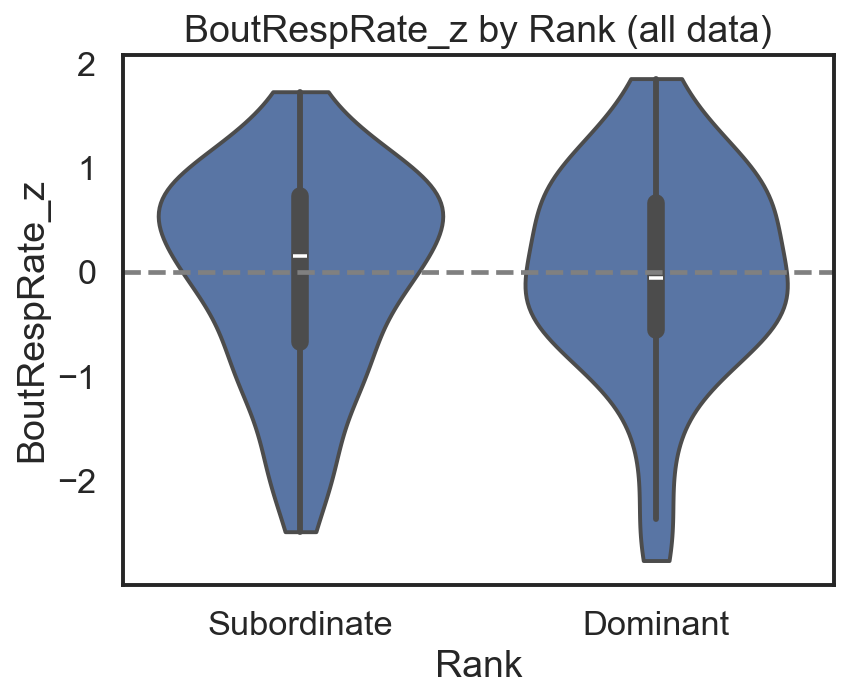

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.violinplot(
    data=rank_df,
    x="Rank", y="BoutRespRate_z",
    inner="box", cut=0
)
plt.axhline(0, color="gray", ls="--")
plt.title("BoutRespRate_z by Rank (all data)")
plt.tight_layout()
plt.show()


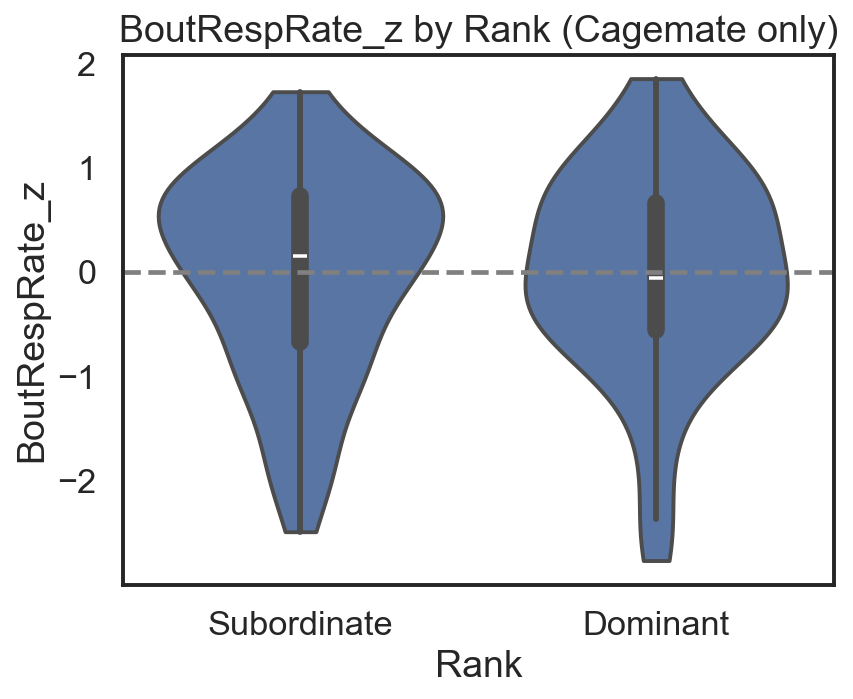

In [261]:
import seaborn as sns
import matplotlib.pyplot as plt

# Keep only cagemate trials
cm_rank_df = rank_df[rank_df["Condition"] == "CM"].copy()

plt.figure(figsize=(6,5))
sns.violinplot(
    data=cm_rank_df,
    x="Rank",
    y="BoutRespRate_z",
    inner="box",
    cut=0
)


plt.axhline(0, color="gray", ls="--")
plt.ylabel("BoutRespRate_z")
plt.xlabel("Rank")
plt.title("BoutRespRate_z by Rank (Cagemate only)")
plt.tight_layout()
plt.show()




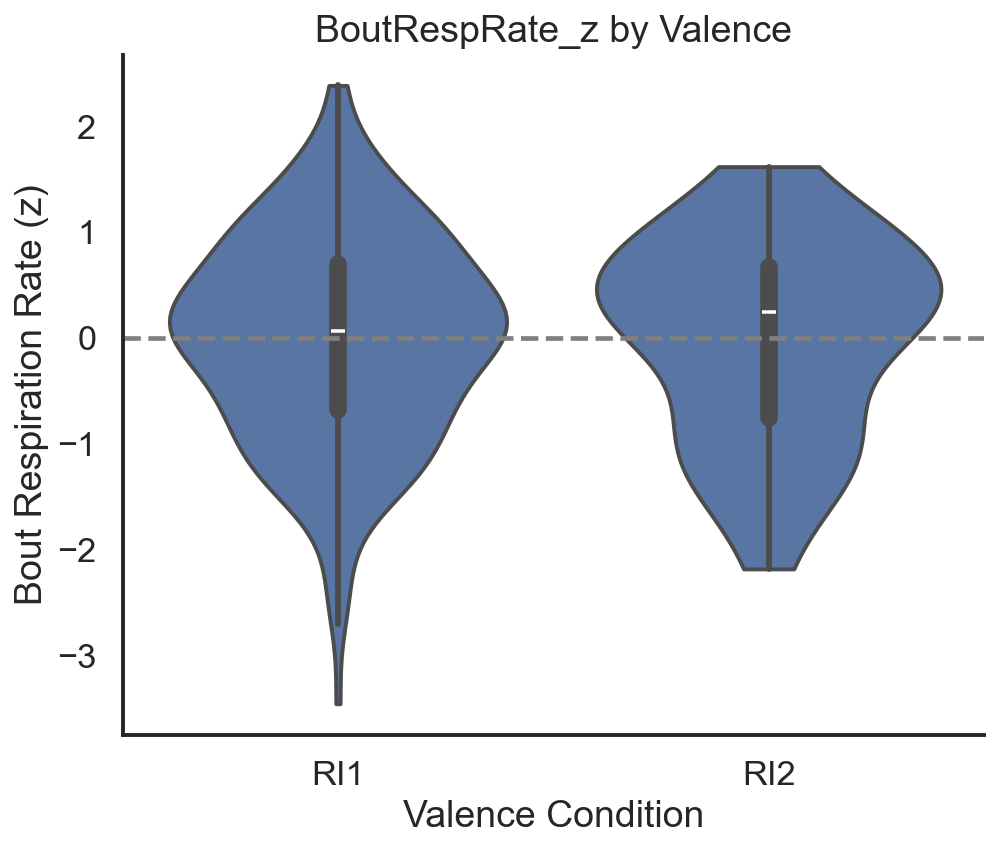

In [255]:
import seaborn as sns
import matplotlib.pyplot as plt

df_val = master_df[
    (master_df["Type"] == "Interaction") &
    (master_df["Condition"].isin(["RI1", "RI2"]))
].copy()

plt.figure(figsize=(7,6))
sns.violinplot(
    data=df_val,
    x="Condition",
    y="BoutRespRate_z",
    inner="box",
    cut=0
)
plt.axhline(0, color="gray", ls="--")
plt.ylabel("Bout Respiration Rate (z)")
plt.xlabel("Valence Condition")
plt.title("BoutRespRate_z by Valence")
sns.despine()
plt.tight_layout()
plt.show()


In [247]:
plot_df = master_df[
    (master_df["Type"] == "Interaction") &
    master_df["BoutRespRate_z"].notna()
].copy()


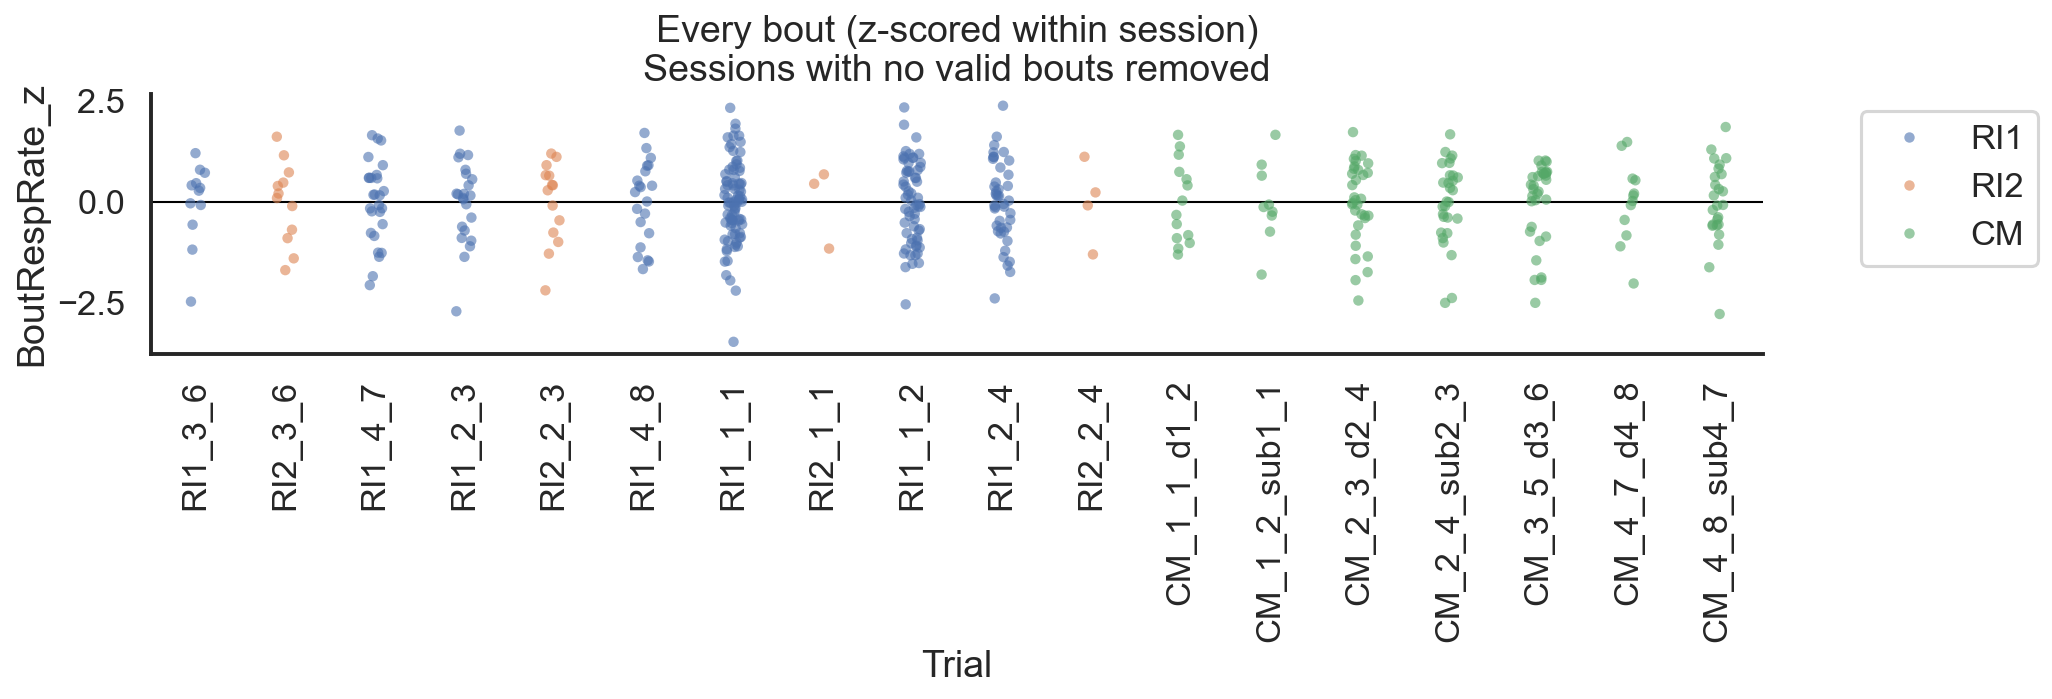

In [249]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
sns.stripplot(
    data=plot_df,
    x="Trial",
    y="BoutRespRate_z",
    hue="Condition",
    alpha=0.6,
    dodge=False
)

plt.axhline(0, color="black", lw=1)
plt.xticks(rotation=90)
plt.ylabel("BoutRespRate_z")
plt.xlabel("Trial")
plt.title("Every bout (z-scored within session)\nSessions with no valid bouts removed")
sns.despine()
plt.tight_layout()
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


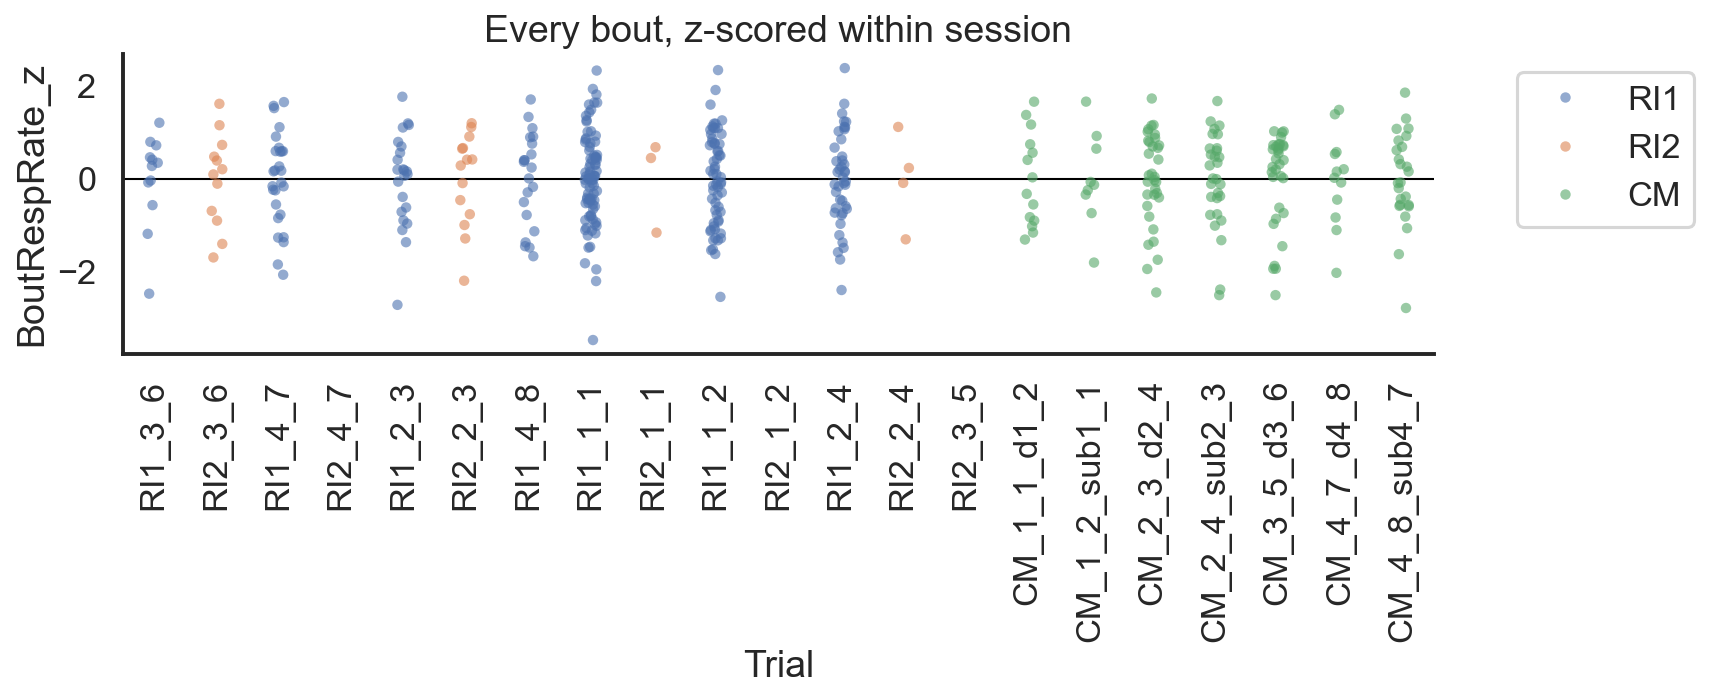

In [244]:
plt.figure(figsize=(10,5))
sns.stripplot(
    data=master_df[
        (master_df["Type"] == "Interaction") &
        (master_df["Condition"].isin(["RI1", "RI2", "CM"]))
    ],
    x="Trial",
    y="BoutRespRate_z",
    hue="Condition",
    alpha=0.6,
    dodge=False
)
plt.axhline(0, color="black", lw=1)
plt.xticks(rotation=90)
plt.ylabel("BoutRespRate_z")
plt.title("Every bout, z-scored within session")
sns.despine()
plt.tight_layout()
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


In [245]:
df_ri2_48 = master_df[
    (master_df["Trial"] == "RI2_4_8") &
    (master_df["Type"] == "Interaction")
][["Behavior", "Start", "Stop", "Duration", "BoutRespRate_z"]]

print(df_ri2_48)


Empty DataFrame
Columns: [Behavior, Start, Stop, Duration, BoutRespRate_z]
Index: []


In [241]:
boris_paths.get("RI2_4_8", "NO BORIS FILE")


'E:\\Aim1\\AIM1\\Day1_new\\boris\\RI2_s4_8_p5_1_nRB3_20250621_HEEPS.csv'

In [242]:
master_df.groupby(["Trial", "Condition"]).size().sort_values()


Trial          Condition
BLRI_1_1       BLRI          1
RI2_3_5        RI2           1
RI2_1_2        RI2           1
RI1_3_5        RI1           1
CM_3_6_sub3_5  CM            1
BL_4_8_sub4_7  BL            1
BL_4_7_d4_8    BL            1
BL_3_6_sub3_5  BL            1
BL_3_5_d3_6    BL            1
BL_2_4_sub2_3  BL            1
RI2_4_7        RI2           1
BL_1_2_sub1_1  BL            1
BL_1_1_d1_2    BL            1
BLRI_4_8       BLRI          1
BLRI_4_7       BLRI          1
BLRI_2_4       BLRI          1
BLRI_2_3       BLRI          1
BLRI_1_2       BLRI          1
BL_2_3_d2_4    BL            1
BLRI_3_6       BLRI          1
RI2_1_1        RI2           3
RI2_2_4        RI2           4
CM_1_2_sub1_1  CM            9
RI2_3_6        RI2          12
RI1_3_6        RI1          12
RI2_2_3        RI2          14
CM_1_1_d1_2    CM           14
CM_4_7_d4_8    CM           15
RI1_4_8        RI1          21
RI1_2_3        RI1          23
CM_4_8_sub4_7  CM           25
RI1_4_7       

In [246]:
boris_df = load_clean_boris(boris_paths["RI2_4_8"])
print(boris_df["Duration"].describe())


count    1.000
mean     0.433
std        NaN
min      0.433
25%      0.433
50%      0.433
75%      0.433
max      0.433
Name: Duration, dtype: float64


In [233]:
subject_means = (
    valence_df
    .groupby(["Subject", "Condition"])["BoutRespRate"]
    .mean()
    .unstack()
)

display(subject_means)

print("\nRI2 − RI1 per subject:")
display(subject_means["RI2"] - subject_means["RI1"])


Condition,RI1,RI2
Subject,,
1_1,8.105338,7.850326
1_2,7.758126,9.901961
2_3,9.019158,9.281666
2_4,9.191267,9.358090
3_5,NaN,10.833333
3_6,9.199412,8.438363
4_7,8.978188,9.850465
4_8,8.725000,NaN



RI2 − RI1 per subject:


Subject
1_1   -0.255012
1_2    2.143834
2_3    0.262507
2_4    0.166822
3_5         NaN
3_6   -0.761048
4_7    0.872278
4_8         NaN
dtype: float64

In [164]:
summary_z = (
    valence_df
    .groupby("Condition")["BoutRespRate_z"]
    .agg(["mean", "std", "count"])
)

display(summary_z)


,mean,std,count
Condition,,,
RI1,3.491979e-16,0.988826,271
RI2,-1.227974e-16,0.951972,33


In [152]:
for pair in pair_groups:
    pair_df = rank_df[rank_df["Subject"].isin(pair)]
    print(f"\nPair {pair}")
    print(pair_df["Rank"].value_counts())
    print("Mean BoutRespRate_z by rank:")
    print(pair_df.groupby("Rank")["BoutRespRate_z"].mean())



Pair ['1_1', '1_2']
Rank
Subordinate    14
Dominant        9
Name: count, dtype: int64
Mean BoutRespRate_z by rank:
Rank
Dominant       8.635068e-17
Subordinate   -4.401241e-16
Name: BoutRespRate_z, dtype: float64

Pair ['2_3', '2_4']
Rank
Subordinate    33
Dominant       29
Name: count, dtype: int64
Mean BoutRespRate_z by rank:
Rank
Dominant      -1.462432e-15
Subordinate   -2.422305e-16
Name: BoutRespRate_z, dtype: float64

Pair ['3_5', '3_6']
Rank
Subordinate    32
Name: count, dtype: int64
Mean BoutRespRate_z by rank:
Rank
Subordinate    5.551115e-17
Name: BoutRespRate_z, dtype: float64

Pair ['4_7', '4_8']
Rank
Dominant       25
Subordinate    12
Name: count, dtype: int64
Mean BoutRespRate_z by rank:
Rank
Dominant       8.970602e-16
Subordinate    7.401487e-17
Name: BoutRespRate_z, dtype: float64


In [234]:
for s in ["3_5", "3_6"]:
    print(f"\nSubject {s}")
    print(master_df.query("Subject == @s")[["Type","Condition","BoutRespRate_z"]].notna().sum())




Subject 3_5
Type              35
Condition         35
BoutRespRate_z    32
dtype: int64

Subject 3_6
Type              27
Condition         27
BoutRespRate_z    24
dtype: int64


In [144]:
master_df.query("Subject in ['4_7','4_8']")[[
    "Subject", "Condition", "Type", "Behavior"
]].value_counts().sort_index()


Subject  Condition  Type         Behavior           
4_7      BLRI       Baseline     Baseline                1
         CM         Interaction  anogenital sniffing     2
                                 body sniffing           9
                                 facial sniffing         4
         RI1        Interaction  anogenital sniffing    11
                                 body sniffing           7
                                 facial sniffing         9
         RI2        Interaction  facial sniffing         1
4_8      BLRI       Baseline     Baseline                1
         CM         Interaction  anogenital sniffing     1
                                 body sniffing           8
                                 facial sniffing        16
         RI1        Interaction  anogenital sniffing     5
                                 body sniffing           8
                                 facial sniffing         8
Name: count, dtype: int64

In [157]:
# ----------------------------------
# Prepare BOUT-LEVEL valence data
# ----------------------------------
valence_df = (
    master_df
    .query("Type == 'Interaction' and Condition in ['RI1', 'RI2']")
    .dropna(subset=["BoutRespRate"])
    .copy()
)

X = valence_df[["BoutRespRate"]].to_numpy()
y = (valence_df["Condition"] == "RI1").astype(int).to_numpy()  # 1 = positive valence
groups = valence_df["Subject"].to_numpy()

# ----------------------------------
# Leave-One-Subject-Out CV
# ----------------------------------
unique_subjects = np.unique(groups)
cv = GroupKFold(n_splits=len(unique_subjects))
aucs = []

print(f"Running Leave-One-Subject-Out Valence CV on {len(unique_subjects)} subjects...\n")

for train_idx, test_idx in cv.split(X, y, groups):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Skip folds without both valences in test
    if len(np.unique(y_test)) < 2:
        subj = np.unique(groups[test_idx])[0]
        print(f" Skipping subject {subj} (test set has one valence)")
        continue

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            C=0.1,
            penalty="l2",
            solver="liblinear",
            class_weight="balanced"
        ))
    ])

    model.fit(X_train, y_train)
    y_pred = model.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, y_pred)
    aucs.append(auc)

    subj = np.unique(groups[test_idx])[0]
    print(f"Subject {subj}: AUC = {auc:.2f}")

# ----------------------------------
#  Summary
# ----------------------------------
if aucs:
    auc_valence_mean = np.mean(aucs)
    auc_valence_sem = np.std(aucs) / np.sqrt(len(aucs))

    print("\n Valence (RI1 vs RI2) AUCs:", np.round(aucs, 3))
    print(f"Mean Valence AUC: {auc_valence_mean:.2f} ± {auc_valence_sem:.2f}")
else:
    print(" No valid subject folds contained both valences.")


Running Leave-One-Subject-Out Valence CV on 8 subjects...

Subject 1_1: AUC = 0.42
Subject 1_2: AUC = 0.97
Subject 2_4: AUC = 0.60
Subject 2_3: AUC = 0.62
Subject 4_7: AUC = 0.85
Subject 3_6: AUC = 0.22
 Skipping subject 4_8 (test set has one valence)
 Skipping subject 3_5 (test set has one valence)

 Valence (RI1 vs RI2) AUCs: [0.421 0.968 0.595 0.624 0.852 0.222]
Mean Valence AUC: 0.61 ± 0.10


In [230]:
# --- Build clean AUC dataframe ---
valid_subjects = []
for train_idx, test_idx in cv.split(X, y, groups):
    y_test = y[test_idx]
    subj = np.unique(groups[test_idx])[0]
    if len(np.unique(y_test)) < 2:
        continue  # skipped folds
    valid_subjects.append(subj)

auc_df = pd.DataFrame({
    "Subject": valid_subjects,
    "AUC": aucs
})

print("\n✅ AUC summary table:")
print(auc_df)



✅ AUC summary table:
  Subject       AUC
0     1_1  0.420635
1     1_2  0.967742
2     2_4  0.595238
3     2_3  0.624224
4     4_7  0.851852
5     3_6  0.222222


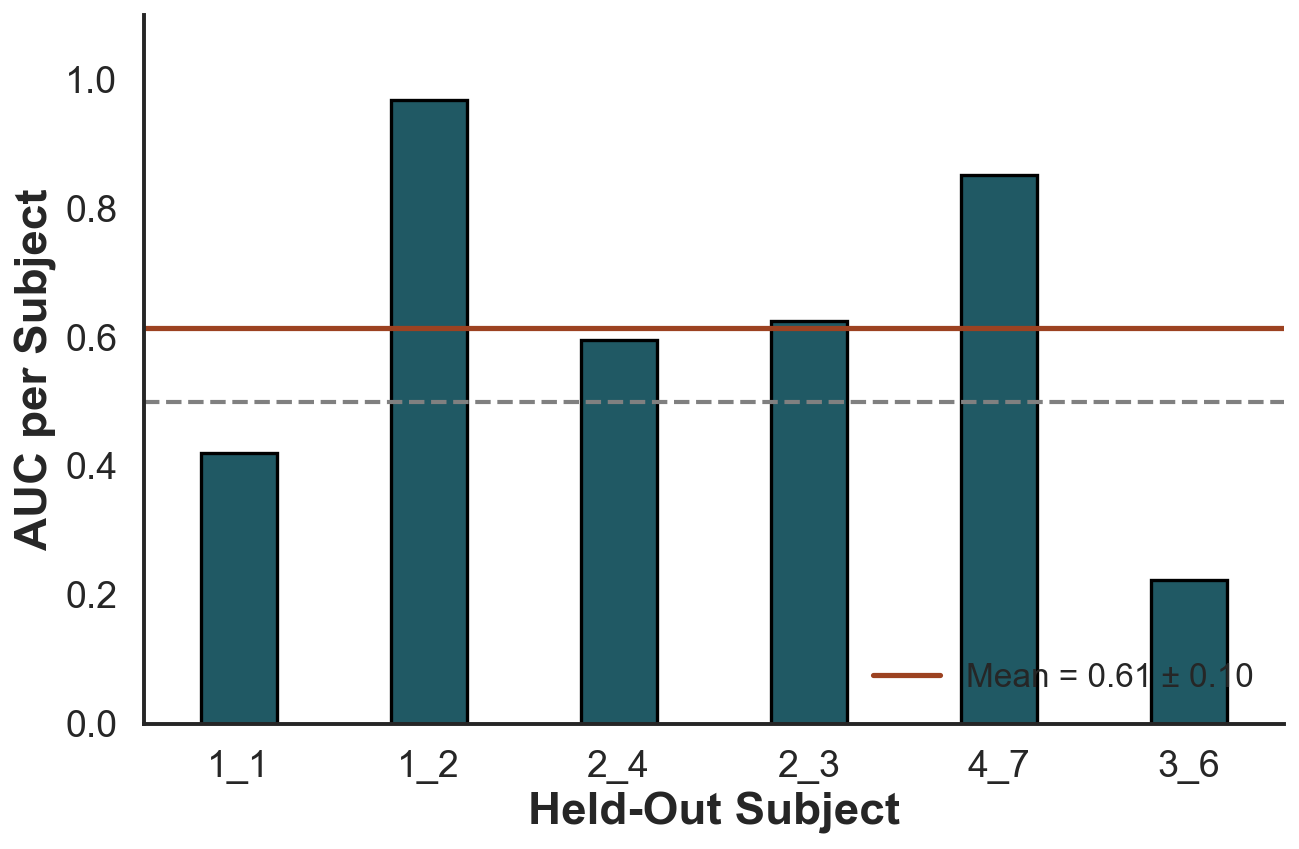

In [231]:
# --- 2️⃣ Plot settings ---
sns.set(style="white", context="talk")
plt.figure(figsize=(9, 6))

# --- 3️⃣ Plot subject-wise AUCs ---
ax = sns.barplot(
    data=auc_df,
    x="Subject",
    y="AUC",
    color="#15616F",  # Padilla lab deep teal
    width=0.4,
    edgecolor="black",
    linewidth=1.6
)

# --- 4️⃣ Add chance line and mean ± SEM ---
mean_auc = np.mean(auc_df["AUC"])
sem_auc = np.std(auc_df["AUC"]) / np.sqrt(len(auc_df))

ax.axhline(0.5, ls="--", color="gray", lw=2)
ax.axhline(mean_auc, color="#9C4221", lw=2.5, label=f"Mean = {mean_auc:.2f} ± {sem_auc:.2f}")
ax.legend(fontsize=16, frameon=False, loc="lower right")

# --- 5️⃣ Format ---
ax.set_ylim(0, 1.1)
ax.set_ylabel("AUC per Subject", fontsize=22, fontweight="bold")
ax.set_xlabel("Held-Out Subject", fontsize=22, fontweight="bold")
ax.tick_params(axis="x", labelsize=18)
ax.tick_params(axis="y", labelsize=18)
sns.despine()
plt.tight_layout()
plt.show()
